# 🧬 Notebook 5: HEBCS Thesis Validation
## Validating the Mathematical Framework for a Universal Wellness Score

### Thesis (from `invent.md`)
> The human body system is a complex bio-chemical plant where various Electro-Bio-Chemical (EBC)
> pathways produce intermediate and final outcomes that govern physiological states.
>
> **Core Proposition:**
> $$f(\text{Inputs} \mid \text{States}) = \prod_{p \in \mathcal{P}} O_p(\text{States})$$
>
> Where $\mathcal{P}$ is the set of EBC pathways, and the aggregate of $O_p$ yields a **Wellness Score**.

### What This Notebook Validates
1. **Pathway Decomposition** — Can health be decomposed into independent EBC pathway scores?
2. **Product-State Formula** — Does a multiplicative (product) aggregation outperform additive (sum)?
3. **Pathway Independence** — Are EBC pathways statistically independent enough to justify the product formula?
4. **Predictive Power** — Does the HEBCS-derived wellness score predict future health events?
5. **Biomarker → Pathway Mapping** — Are the 8 proposed pathways well-supported by available biomarkers?

### EBC Pathways (from thesis)
| # | Pathway | Key Biomarkers Available |
|---|---------|--------------------------|
| 1 | **Metabolic** | BUN, Creatinine, K+, Na, CO2, Glucose, URR, Kt/V, nPCR |
| 2 | **Digestive** | Albumin, Total Protein, Nutrition intake, Elimination data, Cholesterol, Triglycerides |
| 3 | **Neurological** | Mood scores, Sleep hours, Journal entries, Anxiety/Depression indicators |
| 4 | **Hemolytical** | Hemoglobin, Hematocrit, RBC, RDW, MCV, MCH, MCHC, LDH, Reticulocyte, Iron, ISAT, Ferritin, TIBC |
| 5 | **Endocrinology** | PTH, Calcium, Phosphorus, Vitamin D, HbA1c, Glucose |
| 6 | **Digestive/GI** | Bowel movements, Vomit episodes, Bristol scale, Weight changes |
| 7 | **Bone Formation** | Calcium, Phosphorus, Ca×P product, PTH, Vitamin D, ALP |
| 8 | **Immunological** *(extended)* | WBC, Neutrophils, Lymphocytes, Monocytes, Eosinophils, Basophils |

*Note: Reproductive pathway excluded due to insufficient data for single-patient validation.*

In [1]:
# ═══════════════════════════════════════════════════════════
# CELL 1: Setup & Data Loading
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, LeaveOneOut
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             roc_auc_score, classification_report)
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FEATURES_DIR  = PROJECT_ROOT / 'data' / 'features'
MODELS_DIR    = PROJECT_ROOT / 'models'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading processed data from NB01/NB02/NB03/NB04...\n")

# ── Processed data (from NB01) ──
df_labs        = pd.read_csv(PROCESSED_DIR / 'unified_labs.csv')
df_nutrition   = pd.read_csv(PROCESSED_DIR / 'unified_nutrition.csv')
df_elimination = pd.read_csv(PROCESSED_DIR / 'unified_elimination.csv')
df_dialysis_s  = pd.read_csv(PROCESSED_DIR / 'dialysis_sessions.csv')
df_dialysis_r  = pd.read_csv(PROCESSED_DIR / 'dialysis_readings.csv')
df_mood        = pd.read_csv(PROCESSED_DIR / 'journal_mood.csv')
df_medications = pd.read_csv(PROCESSED_DIR / 'medications.csv')
df_vitals      = pd.read_csv(PROCESSED_DIR / 'vitals.csv')
df_symptoms    = pd.read_csv(PROCESSED_DIR / 'symptoms.csv')

# Derive vomit subset from unified_elimination (vomit merged in NB01)
if 'type' in df_elimination.columns:
    df_vomit = df_elimination[df_elimination['type'] == 'vomit'].copy()
    df_bowel = df_elimination[df_elimination['type'] == 'bowel'].copy()
else:
    df_vomit = pd.DataFrame()
    df_bowel = df_elimination.copy()

# ── Features & scores (from NB03/NB04) ──
df_features    = pd.read_csv(FEATURES_DIR / 'health_features.csv', index_col='date', parse_dates=True)
df_scores      = pd.read_csv(FEATURES_DIR / 'health_scores.csv', index_col='date', parse_dates=True)

print(f"  Unified Labs:       {len(df_labs):>6,} records  ({df_labs['test_name'].nunique()} unique tests)")
print(f"  Nutrition:          {len(df_nutrition):>6,} records")
print(f"  Elimination:        {len(df_elimination):>6,} records  ({len(df_bowel)} bowel + {len(df_vomit)} vomit)")
print(f"  Dialysis Sessions:  {len(df_dialysis_s):>6,} records")
print(f"  Dialysis Readings:  {len(df_dialysis_r):>6,} records")
print(f"  Medications:        {len(df_medications):>6,} records")
print(f"  Vitals:             {len(df_vitals):>6,} records")
print(f"  Mood/Journal:       {len(df_mood):>6,} records")
print(f"  Symptoms:           {len(df_symptoms):>6,} records")
print(f"  Health Features:    {df_features.shape[0]:>6,} days × {df_features.shape[1]} features")
print(f"  Health Scores:      {df_scores.shape[0]:>6,} days × {df_scores.shape[1]} score cols")
print(f"\n  Lab date range: {df_labs['date'].min()} → {df_labs['date'].max()}")
print(f"  Score columns: {list(df_scores.columns)}")

Loading processed data from NB01/NB02/NB03/NB04...

  Unified Labs:        9,660 records  (341 unique tests)
  Nutrition:           4,094 records
  Elimination:         3,844 records  (2469 bowel + 1375 vomit)
  Dialysis Sessions:   1,797 records
  Dialysis Readings:  15,711 records
  Medications:           953 records
  Vitals:                 15 records
  Mood/Journal:            5 records
  Symptoms:                1 records
  Health Features:     3,586 days × 347 features
  Health Scores:       3,586 days × 8 score cols

  Lab date range: 2016-04-28 → 2026-02-09
  Score columns: ['score_dialysis', 'score_labs', 'score_nutrition', 'score_elimination', 'score_mood_sleep', 'score_vitals', 'score_activity', 'holistic_score']


In [2]:
# ═══════════════════════════════════════════════════════════
# CELL 2: Build Lab Pivot from Unified Labs
# ═══════════════════════════════════════════════════════════

# unified_labs columns: date, test_name, value, unit, ..., value_numeric, source
labs = df_labs.copy()
labs['date'] = pd.to_datetime(labs['date'], errors='coerce')
labs = labs.dropna(subset=['date'])
labs['date'] = labs['date'].dt.normalize()

print(f"Unified labs: {len(labs):,} records")
print(f"Date range: {labs['date'].min().date()} → {labs['date'].max().date()}")
print(f"Unique tests: {labs['test_name'].nunique()}")

# ── Normalize test names for pathway mapping ──
# Map actual test_name values (including typos/variations) to canonical names
LAB_ALIASES = {
    'BUN':          ['BUN', 'BUN -', 'BUN-P', 'BUN -POST'],
    'Creatinine':   ['Creatnine', 'CRE', 'CREATININE', 'Creatnine POST'],
    'Potassium':    ['Potassium', 'K+', 'POTASSIUM'],
    'Sodium':       ['Sodium', 'Na', 'SODIUM'],
    'CO2':          ['CO2 (Bicarbonate)', 'CO2', 'CO2 POST'],
    'Chloride':     ['Chloride', 'Cl', 'CHLORIDE'],
    'Calcium':      ['Calcium', 'CA', 'Calcium Corrected', 'CA CORR', 'CALCIUM',
                     'CA CORRECTED', 'Calcium POST'],
    'Phosphorus':   ['Phosphorous', 'PHOS', 'Phosphorous POST', 'PHOSPHORUS'],
    'CaxP':         ['CAxPHOS Product', 'CAxPHOS Corrected', 'CA*POCOR', 'CA/P'],
    'Albumin':      ['Albumin', 'ALB', 'ALBUMIN'],
    'Hemoglobin':   ['Hemoglobin', 'HGB', 'HEMOGLOBIN', 'HGBX', 'HGBX3'],
    'Hematocrit':   ['Hematocrit', 'HCT CALC (HBGX3)', 'HCT%', 'HEMATOCRIT'],
    'RBC':          ['RBC'],
    'RDW':          ['RDW'],
    'MCV':          ['MCV'],
    'MCH':          ['MCH'],
    'MCHC':         ['MCHC'],
    'WBC':          ['WBC', 'Leukocyte count'],
    'Platelets':    ['Platelet CT', 'PLT'],
    'Neutrophils':  ['NEUTS-ABS', 'NEUTROPHILS', 'Neutrophils %'],
    'Lymphocytes':  ['LYMPHS-ABS', 'LYMPHOCYTES', 'Lymphocytes'],
    'Monocytes':    ['MONOS-ABS', 'MONOCYTES', 'Monocytes %'],
    'Eosinophils':  ['EOSINS-ABS', 'EOSINOPHILS', 'Eonsinophils'],
    'Basophils':    ['BASOS-ABS', 'BASO', 'Basophils', 'BASOPHILS'],
    'LDH':          ['LDH(Total)', 'LDH'],
    'Iron':         ['Iron', 'FE', 'IRON'],
    'ISAT':         ['Iron Saturation', 'ISAT', 'Iron/TIBC %'],
    'Ferritin':     ['Ferritin', 'FERR', 'FERRITIN'],
    'TIBC':         ['TIBC'],
    'UIBC':         ['UIBC'],
    'PTH':          ['PTH Intact', 'PTH-I', 'PTH-INTACT', 'PTH POST'],
    'Vitamin_D':    ['Vitamin D(25-OH)', 'VIT D'],
    'ALP':          ['ALK PHOS', 'ALP'],
    'Glucose':      ['Glucose', 'GLU', 'GLUCOSE'],
    'HbA1c':        ['HGB A1c'],
    'Cholesterol':  ['Cholesterol'],
    'HDL':          ['HDL'],
    'LDL':          ['LDL'],
    'Triglycerides': ['Triglyceride'],
    'Total_Protein': ['Protein -Total', 'TPRO'],
    'Globulin':     ['Globulin', 'GLOB', 'GLOBULIN'],
    'ALT':          ['ALT', 'ALT/SGPT'],
    'AST':          ['SGOT(AST)', 'AST', 'AST/SGOT'],
    'URR':          ['uRR', 'URR', 'URR%'],
    'KtV':          ['spKdt/V Dialysis', 'eKdt/V Dialysis', 'stdKdT/V Dialysis',
                     'spKt/V', 'eKt/V', 'eKdt/V', 'Kt/V Prescribed'],
    'nPCR':         ['nPCR'],
    'Reticulocyte': ['Reticulocytes, Absolute', 'Reticulocyte Count, Absolute, Automated',
                     'Reticulocyte Hemoglobin, Automated Count'],
    'B12':          ['VIT B12'],
    'Folate':       ['Folate'],
    'Magnesium':    ['Magnessium', 'MG', 'MAGNESIUM'],
    'Uric_Acid':    [],
    'Anion_Gap':    ['Anion Gap'],
}

# Invert: raw_name → canonical
raw_to_canonical = {}
for canonical, aliases in LAB_ALIASES.items():
    for alias in aliases:
        raw_to_canonical[alias] = canonical

labs['test_canonical'] = labs['test_name'].map(raw_to_canonical)
mapped = labs.dropna(subset=['test_canonical'])
unmapped = labs[labs['test_canonical'].isna()]['test_name'].unique()
print(f"\nMapped: {len(mapped):,} / {len(labs):,} lab results ({len(mapped)/len(labs)*100:.1f}%)")
print(f"Unmapped tests ({len(unmapped)}): {list(unmapped)[:15]}...")

# ── Pivot: one row per date, one column per canonical test ──
lab_pivot = mapped.pivot_table(
    index='date', columns='test_canonical', values='value_numeric',
    aggfunc='mean'  # average if multiple same-day tests
).sort_index()

print(f"\nLab pivot: {lab_pivot.shape[0]} dates × {lab_pivot.shape[1]} tests")
print(f"\nCoverage per test:")
coverage = lab_pivot.notna().sum().sort_values(ascending=False)
for test, count in coverage.head(25).items():
    print(f"  {test:20s}: {count:3d} dates ({count/len(lab_pivot)*100:5.1f}%)")

Unified labs: 9,660 records
Date range: 2016-04-28 → 2026-02-09
Unique tests: 341

Mapped: 8,557 / 9,660 lab results (88.6%)
Unmapped tests (210): ['A/G Ratio', 'Aluminium', 'HEB B Surface Ag', 'HEP B Core Ab', 'HEP B Surface Ab', 'HEP C AB Reflex', 'VM', 'spdKt/V Total', 'GFR', 'BSA', 'Weight', 'Heptoglobin', 'Hemoglobin POCT', 'Hemotacrit POCT', 'MPV']...

Lab pivot: 308 dates × 51 tests

Coverage per test:
  Hematocrit          : 260 dates ( 84.4%)
  BUN                 : 235 dates ( 76.3%)
  Hemoglobin          : 231 dates ( 75.0%)
  Potassium           : 223 dates ( 72.4%)
  Creatinine          : 215 dates ( 69.8%)
  Chloride            : 202 dates ( 65.6%)
  Calcium             : 201 dates ( 65.3%)
  CO2                 : 199 dates ( 64.6%)
  Phosphorus          : 190 dates ( 61.7%)
  Sodium              : 188 dates ( 61.0%)
  RBC                 : 181 dates ( 58.8%)
  Platelets           : 177 dates ( 57.5%)
  Glucose             : 176 dates ( 57.1%)
  WBC                 : 174 

---
## Part 1: EBC Pathway Decomposition
### Mapping Biomarkers → Pathways

The thesis proposes that health can be decomposed into independent Electro-Bio-Chemical pathways.
We define each pathway's scoring function using available biomarkers, with clinically established
reference ranges for an ESRD patient on home hemodialysis.

Each pathway produces a score $O_p \in [0, 1]$ where:
- $O_p = 1.0$ → optimal physiological state for this pathway
- $O_p = 0.0$ → critically abnormal

The scoring uses a **trapezoidal membership function** that maps lab values to pathway scores
based on reference ranges:

$$O_p = \frac{1}{|B_p|} \sum_{b \in B_p} w_b \cdot \mu(b)$$

where $B_p$ is the set of biomarkers for pathway $p$, $w_b$ is the clinical weight, and
$\mu(b)$ is the normalized score for biomarker $b$.

In [3]:
# ═══════════════════════════════════════════════════════════
# CELL 3: Define EBC Pathway Scoring Functions
# ═══════════════════════════════════════════════════════════

def trapezoidal_score(value, critical_low, optimal_low, optimal_high, critical_high):
    """
    Trapezoidal membership function mapping a biomarker value to [0, 1].

    Score = 1.0 within [optimal_low, optimal_high]
    Score ramps linearly from 0→1 between critical_low→optimal_low
    Score ramps linearly from 1→0 between optimal_high→critical_high
    Score = 0.0 outside [critical_low, critical_high]

    For one-sided ranges (e.g. "lower is better"), set critical_low/optimal_low to -inf.
    """
    if pd.isna(value):
        return np.nan
    if critical_low is None:
        critical_low = -np.inf
    if critical_high is None:
        critical_high = np.inf
    if optimal_low is None:
        optimal_low = critical_low
    if optimal_high is None:
        optimal_high = critical_high

    if value <= critical_low or value >= critical_high:
        return 0.0
    elif optimal_low <= value <= optimal_high:
        return 1.0
    elif value < optimal_low:
        return (value - critical_low) / (optimal_low - critical_low) if optimal_low != critical_low else 1.0
    else:  # value > optimal_high
        return (critical_high - value) / (critical_high - optimal_high) if critical_high != optimal_high else 1.0


# ── PATHWAY DEFINITIONS ──
# Each pathway: list of (test_canonical, weight, critical_low, optimal_low, optimal_high, critical_high)
# Reference ranges calibrated for ESRD/HHD patient

PATHWAY_BIOMARKERS = {
    'Metabolic': [
        # Renal clearance & electrolyte balance
        ('BUN',        1.0,   5,  10,  50,  90),     # mg/dL — ESRD patients run higher
        ('Creatinine', 0.8,   2,   4,  12,  18),     # mg/dL — elevated baseline in ESRD
        ('Potassium',  1.5,   2.5, 3.5, 5.0, 6.5),   # mEq/L — critical range
        ('Sodium',     1.0, 125, 135, 145, 155),       # mEq/L
        ('CO2',        1.0,  15,  22,  29,  35),       # mEq/L — bicarbonate
        ('Chloride',   0.5,  90,  96, 106, 115),       # mEq/L
        ('Glucose',    0.8,  40,  70, 140, 250),       # mg/dL — non-diabetic range
        ('URR',        1.2,  40,  65, 100, None),      # % — dialysis adequacy
        ('KtV',        1.2,   0.5, 1.2, 2.5, None),   # dialysis adequacy
        ('nPCR',       0.6,   0.4, 0.8, 1.4, 2.0),    # protein catabolic rate
    ],
    'Digestive': [
        # Nutritional absorption, protein status, lipids
        ('Albumin',       1.5,  1.5, 3.5, 5.0, 6.0),    # g/dL — critical for malnutrition
        ('Total_Protein', 1.0,  4.0, 6.0, 8.3, 10.0),   # g/dL
        ('Cholesterol',   0.7,  80, 120, 200, 300),       # mg/dL
        ('HDL',           0.6,  15,  40,  80, None),      # mg/dL — higher is better
        ('LDL',           0.6, None, None, 130, 200),     # mg/dL — lower is better
        ('Triglycerides', 0.6, None, None, 150, 500),     # mg/dL — lower is better
        ('ALT',           0.4, None, None,  40, 100),     # U/L — liver function
        ('AST',           0.4, None, None,  40, 100),     # U/L
        ('B12',           0.5, 100, 200, 900, 2000),      # pg/mL
        ('Folate',        0.4,  2,   4,  20,  50),        # ng/mL
    ],
    'Neurological': [
        # Electrolytes affecting neural function + mood/sleep data
        ('Sodium',     1.0, 125, 135, 145, 155),   # critical for neural function
        ('Potassium',  0.8,   2.5, 3.5, 5.0, 6.5),
        ('Calcium',    1.0,   6.0, 8.5, 10.5, 13.0),
        ('Magnesium',  0.8,   1.0, 1.5, 2.5, 3.5),
        ('Glucose',    0.6,  40,  70, 140, 250),        # hypoglycemia → neuro symptoms
        ('B12',        0.7, 100, 200, 900, 2000),       # neurological function
    ],
    'Hemolytical': [
        # Red blood cell production, iron metabolism, hemolysis markers
        ('Hemoglobin',   1.5,   5,  10,  13,  18),       # g/dL — anemia in CKD
        ('Hematocrit',   1.2,  18,  30,  42,  55),       # %
        ('RBC',          1.0,   2.0, 3.5, 5.5, 7.0),    # M/uL
        ('RDW',          0.8, None, None, 14.5, 20),     # % — elevated = hemolysis/iron deficiency
        ('MCV',          0.7,  60,  80, 100, 120),       # fL
        ('MCH',          0.5,  20,  27,  33,  40),       # pg
        ('MCHC',         0.5,  28,  32,  36,  40),       # g/dL
        ('Iron',         0.8,  20,  60, 170, 300),       # mcg/dL
        ('ISAT',         1.0,  10,  20,  50,  80),       # % — ESRD target 20-50%
        ('Ferritin',     1.0,  50, 200, 500, 1200),      # ng/mL — ESRD target 200-500
        ('TIBC',         0.6, 150, 250, 370, 500),       # mcg/dL
        ('LDH',          0.8, None, None, 250, 500),     # U/L — hemolysis marker
        ('Reticulocyte', 0.6,  10,  25, 100, 200),       # K/uL — bone marrow response
    ],
    'Endocrinology': [
        # Parathyroid, mineral metabolism, glucose regulation
        ('PTH',       1.5,   5, 150, 600, 1200),         # pg/mL — ESRD range 150-600
        ('Calcium',   1.2,   6.0, 8.5, 10.5, 13.0),     # mg/dL
        ('Phosphorus', 1.2,  1.5, 3.5, 5.5, 9.0),       # mg/dL — ESRD target 3.5-5.5
        ('Vitamin_D', 1.0,   5,  30,  80, 150),          # ng/mL
        ('HbA1c',     0.8, None, None, 6.5, 10),         # % — glycemic control
        ('Glucose',   0.8,  40,  70, 140, 250),          # mg/dL
    ],
    'Bone_Formation': [
        # Mineral bone disease (CKD-MBD)
        ('Calcium',    1.5,   6.0, 8.5, 10.5, 13.0),
        ('Phosphorus', 1.5,   1.5, 3.5, 5.5, 9.0),
        ('CaxP',       1.2, None, None,  55,  80),       # Ca × P product — calcification risk
        ('PTH',        1.5,   5, 150, 600, 1200),
        ('Vitamin_D',  1.2,   5,  30,  80, 150),
        ('ALP',        0.8,  20,  44, 147, 300),         # U/L — bone turnover
        ('Magnesium',  0.6,   1.0, 1.5, 2.5, 3.5),
    ],
    'Immunological': [
        # Immune system function
        ('WBC',          1.5,   1.5, 4.5, 11.0, 20.0),  # K/uL
        ('Neutrophils',  1.0,   0.5, 1.8,  7.0, 15.0),  # K/uL
        ('Lymphocytes',  1.0,   0.3, 1.0,  4.0, 10.0),  # K/uL
        ('Monocytes',    0.5,   0.1, 0.2,  0.8,  2.0),  # K/uL
        ('Eosinophils',  0.3, None, None,  0.5,  1.5),   # K/uL
        ('Basophils',    0.2, None, None,  0.1,  0.5),   # K/uL
        ('Platelets',    0.8,  50, 150, 400, 600),       # K/uL
    ],
}

print("EBC Pathway Definitions:")
print(f"{'Pathway':<18} {'Biomarkers':>10} {'Max Weight':>12}")
print("─" * 42)
for pathway, markers in PATHWAY_BIOMARKERS.items():
    total_w = sum(m[1] for m in markers)
    print(f"  {pathway:<16} {len(markers):>8}   {total_w:>10.1f}")
print(f"\nTotal unique biomarkers across all pathways: "
      f"{len(set(m[0] for markers in PATHWAY_BIOMARKERS.values() for m in markers))}")

EBC Pathway Definitions:
Pathway            Biomarkers   Max Weight
──────────────────────────────────────────
  Metabolic              10          9.6
  Digestive              10          6.7
  Neurological            6          4.9
  Hemolytical            13         11.0
  Endocrinology           6          6.5
  Bone_Formation          7          8.3
  Immunological           7          5.3

Total unique biomarkers across all pathways: 48


In [4]:
# ═══════════════════════════════════════════════════════════
# CELL 4: Compute Pathway Scores Over Time
# ═══════════════════════════════════════════════════════════

def compute_pathway_scores(lab_pivot, pathway_defs):
    """
    Compute O_p(t) for each pathway p at each time point t.

    Returns DataFrame with columns: date, pathway_name, score, n_markers, markers_available
    """
    results = []

    for date_idx in lab_pivot.index:
        row = lab_pivot.loc[date_idx]

        for pathway_name, markers in pathway_defs.items():
            weighted_sum = 0.0
            weight_sum = 0.0
            n_available = 0
            available_markers = []

            for test, weight, crit_lo, opt_lo, opt_hi, crit_hi in markers:
                if test in row.index and pd.notna(row[test]):
                    score = trapezoidal_score(row[test], crit_lo, opt_lo, opt_hi, crit_hi)
                    weighted_sum += weight * score
                    weight_sum += weight
                    n_available += 1
                    available_markers.append(test)

            if n_available > 0:
                pathway_score = weighted_sum / weight_sum  # normalized to [0, 1]
            else:
                pathway_score = np.nan

            results.append({
                'date': date_idx,
                'pathway': pathway_name,
                'score': pathway_score,
                'n_markers': n_available,
                'total_markers': len(markers),
                'markers_available': ', '.join(available_markers)
            })

    return pd.DataFrame(results)


pathway_scores = compute_pathway_scores(lab_pivot, PATHWAY_BIOMARKERS)

# Pivot for analysis: dates × pathways
pathway_pivot = pathway_scores.pivot_table(
    index='date', columns='pathway', values='score'
).sort_index()

print(f"Pathway scores computed: {len(pathway_scores):,} (pathway × date) entries")
print(f"\nPathway coverage (dates with scores):")
for col in pathway_pivot.columns:
    n = pathway_pivot[col].notna().sum()
    print(f"  {col:<18}: {n:>3} / {len(pathway_pivot)} dates "
          f"({n/len(pathway_pivot)*100:.0f}%)")

print(f"\nMean pathway scores:")
for col in pathway_pivot.columns:
    mean = pathway_pivot[col].mean()
    std = pathway_pivot[col].std()
    print(f"  {col:<18}: {mean:.3f} ± {std:.3f}")

Pathway scores computed: 2,156 (pathway × date) entries

Pathway coverage (dates with scores):
  Bone_Formation    : 217 / 308 dates (70%)
  Digestive         : 170 / 308 dates (55%)
  Endocrinology     : 233 / 308 dates (76%)
  Hemolytical       : 285 / 308 dates (93%)
  Immunological     : 190 / 308 dates (62%)
  Metabolic         : 246 / 308 dates (80%)
  Neurological      : 242 / 308 dates (79%)

Mean pathway scores:
  Bone_Formation    : 0.685 ± 0.190
  Digestive         : 0.977 ± 0.050
  Endocrinology     : 0.708 ± 0.195
  Hemolytical       : 0.671 ± 0.336
  Immunological     : 0.505 ± 0.246
  Metabolic         : 0.787 ± 0.150
  Neurological      : 0.887 ± 0.159


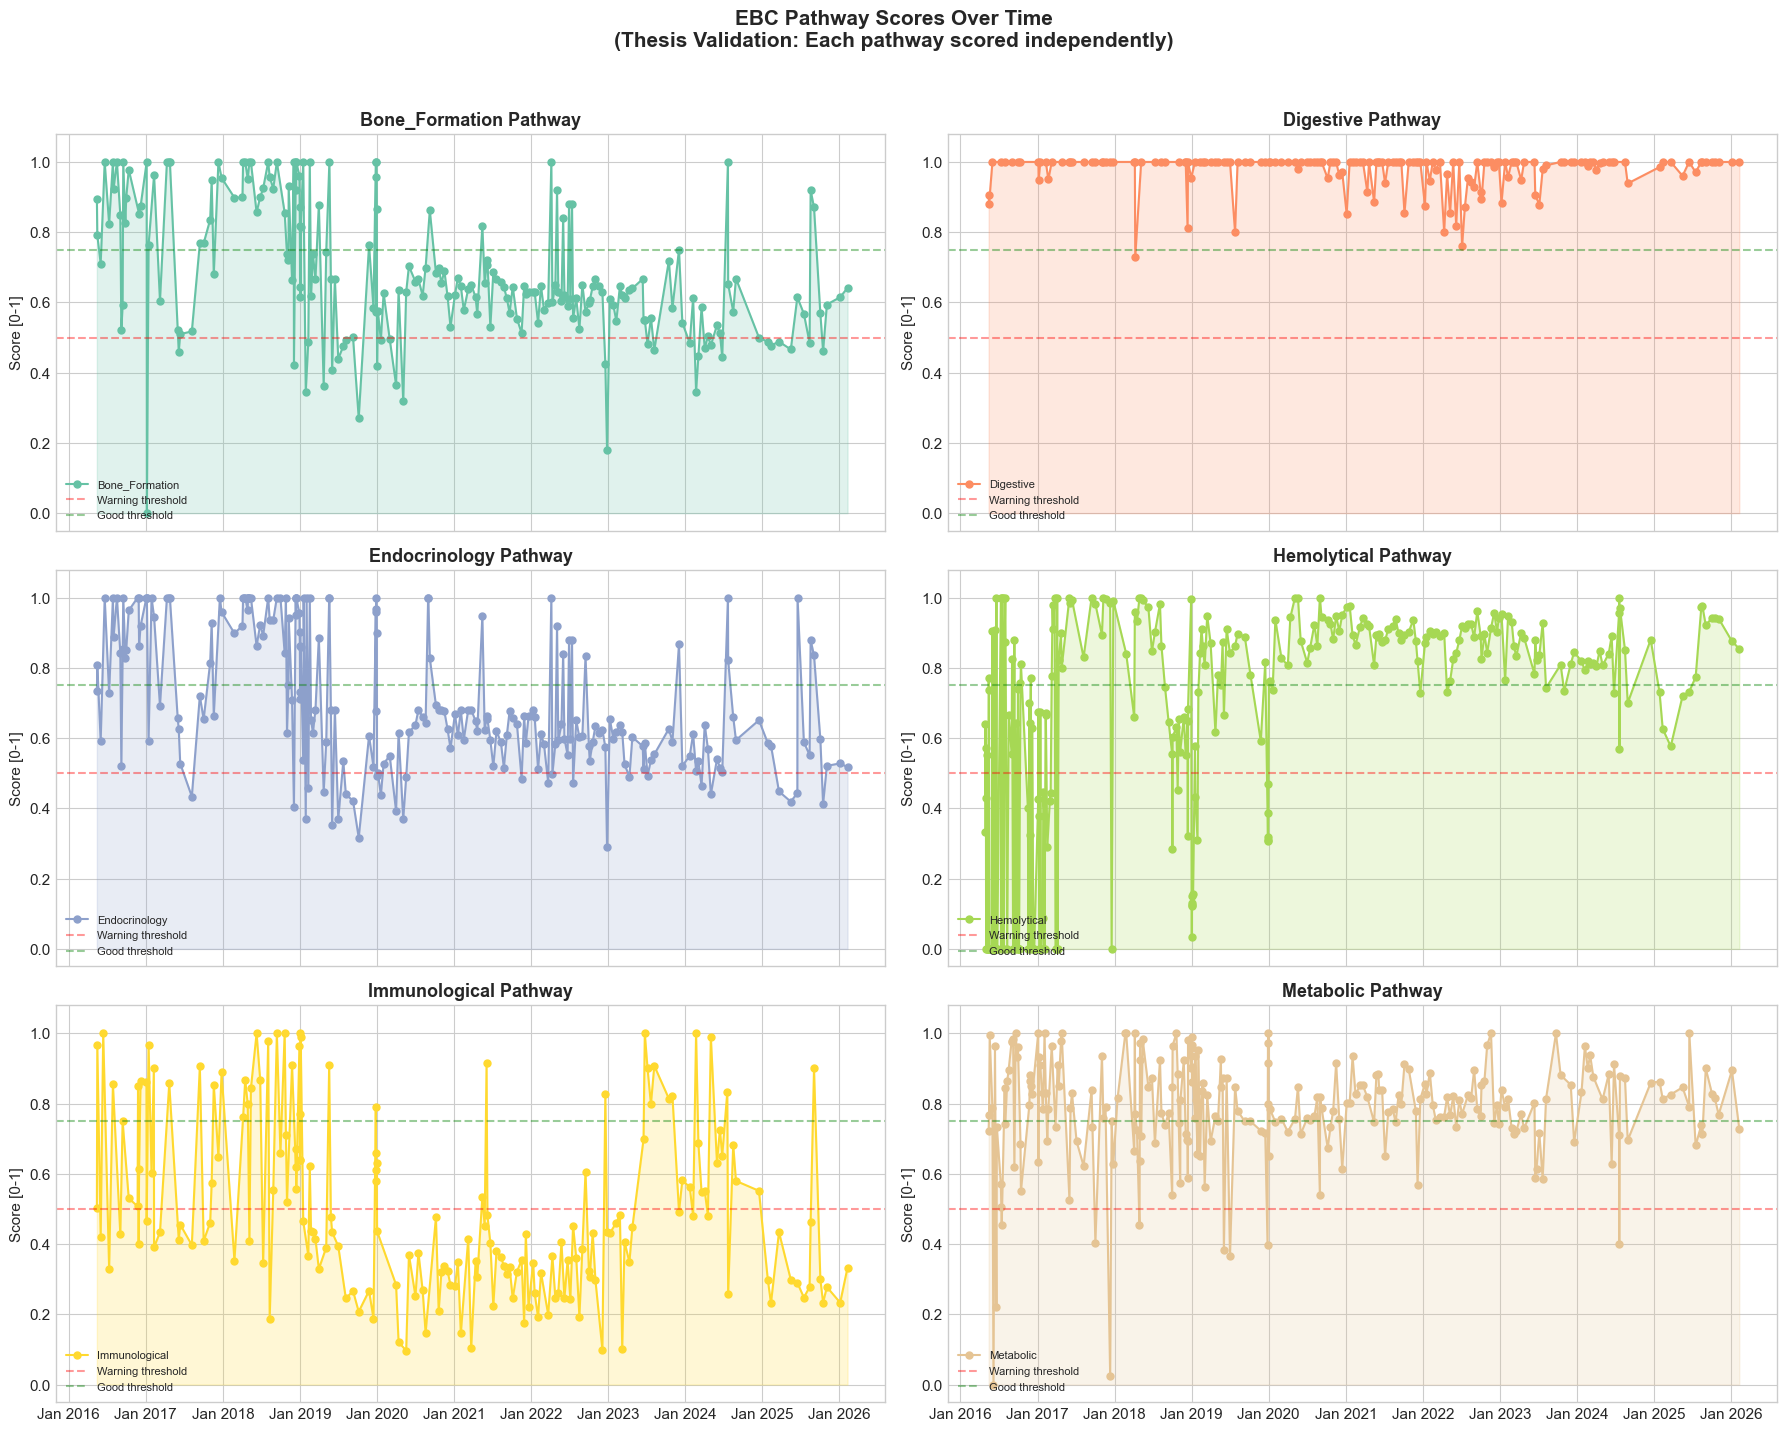

Saved: pathway_scores_timeline.png


In [5]:
# ═══════════════════════════════════════════════════════════
# CELL 5: Visualize Pathway Scores Over Time
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex=True)
axes = axes.flatten()

colors = plt.cm.Set2(np.linspace(0, 1, len(pathway_pivot.columns)))

for i, (pathway, color) in enumerate(zip(sorted(pathway_pivot.columns), colors)):
    if i >= len(axes):
        break
    ax = axes[i]
    data = pathway_pivot[pathway].dropna()
    if len(data) > 0:
        ax.plot(data.index, data.values, 'o-', color=color, markersize=5, linewidth=1.5, label=pathway)
        ax.fill_between(data.index, data.values, alpha=0.2, color=color)
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Warning threshold')
        ax.axhline(y=0.75, color='green', linestyle='--', alpha=0.4, label='Good threshold')
        ax.set_ylabel('Score [0-1]')
        ax.set_title(f'{pathway} Pathway', fontsize=13, fontweight='bold')
        ax.set_ylim(-0.05, 1.08)
        ax.legend(loc='lower left', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('EBC Pathway Scores Over Time\n(Thesis Validation: Each pathway scored independently)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'pathway_scores_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pathway_scores_timeline.png")

---
## Part 2: Testing the Product-State Formula
### Thesis Proposition: $f(\text{Inputs} | \text{States}) = \prod O_p$

The thesis proposes a **multiplicative** (product) aggregation of pathway outputs.
We test three aggregation methods and compare their properties:

| Method | Formula | Properties |
|--------|---------|------------|
| **Additive** (baseline) | $W = \frac{1}{N} \sum_{p} O_p$ | Linear, tolerates one bad pathway |
| **Product** (thesis) | $W = \prod_{p} O_p^{w_p}$ | Multiplicative, one bad pathway tanks the score |
| **Geometric Mean** (compromise) | $W = \left(\prod_{p} O_p\right)^{1/N}$ | Captures product intuition, less extreme |

The product formulation has a crucial biological intuition: **a single failing pathway
degrades the entire system** — e.g., severe anemia ($O_{hemo} \to 0$) causes systemic failure
regardless of how good other pathways are.

In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 6: Compute Wellness Scores — Three Aggregation Methods
# ═══════════════════════════════════════════════════════════

# Define pathway weights for the HEBCS (importance of each pathway)
PATHWAY_WEIGHTS = {
    'Metabolic':     0.20,
    'Digestive':     0.12,
    'Neurological':  0.10,
    'Hemolytical':   0.22,
    'Endocrinology': 0.15,
    'Bone_Formation': 0.10,
    'Immunological': 0.11,
}

# Only use dates where we have at least 3 pathways scored
min_pathways = 3
valid_dates = pathway_pivot.dropna(thresh=min_pathways).index

print(f"Dates with ≥{min_pathways} pathway scores: {len(valid_dates)}")

wellness_scores = pd.DataFrame(index=valid_dates)

for date in valid_dates:
    row = pathway_pivot.loc[date].dropna()
    available_pathways = row.index.tolist()
    scores = row.values
    weights = np.array([PATHWAY_WEIGHTS.get(p, 0.1) for p in available_pathways])
    weights = weights / weights.sum()  # normalize to sum=1

    # ── Method 1: Additive (weighted mean) ──
    wellness_scores.loc[date, 'W_additive'] = np.average(scores, weights=weights)

    # ── Method 2: Product (thesis formula) ──
    # W = ∏ O_p^w_p  (weighted product)
    # Clip scores to avoid log(0)
    clipped = np.clip(scores, 1e-6, 1.0)
    log_product = np.sum(weights * np.log(clipped))
    wellness_scores.loc[date, 'W_product'] = np.exp(log_product)

    # ── Method 3: Geometric mean ──
    wellness_scores.loc[date, 'W_geometric'] = np.exp(np.mean(np.log(clipped)))

    # ── Store individual pathway scores ──
    for p in available_pathways:
        wellness_scores.loc[date, f'pathway_{p}'] = row[p]

    wellness_scores.loc[date, 'n_pathways'] = len(available_pathways)

# Scale to 0-100 for interpretability
for method in ['W_additive', 'W_product', 'W_geometric']:
    wellness_scores[f'{method}_100'] = wellness_scores[method] * 100

print(f"\nWellness Score Summary:")
print(wellness_scores[['W_additive_100', 'W_product_100', 'W_geometric_100', 'n_pathways']].describe().round(2))

Dates with ≥3 pathway scores: 246

Wellness Score Summary:
       W_additive_100  W_product_100  W_geometric_100  n_pathways
count          246.00         246.00           246.00      246.00
mean            76.00          70.66            70.11        6.13
std             11.27          18.53            18.72        1.28
min              0.00           0.00             0.00        3.00
25%             71.10          67.03            65.09        6.00
50%             76.71          73.42            71.54        7.00
75%             80.80          78.88            78.92        7.00
max            100.00         100.00           100.00        7.00


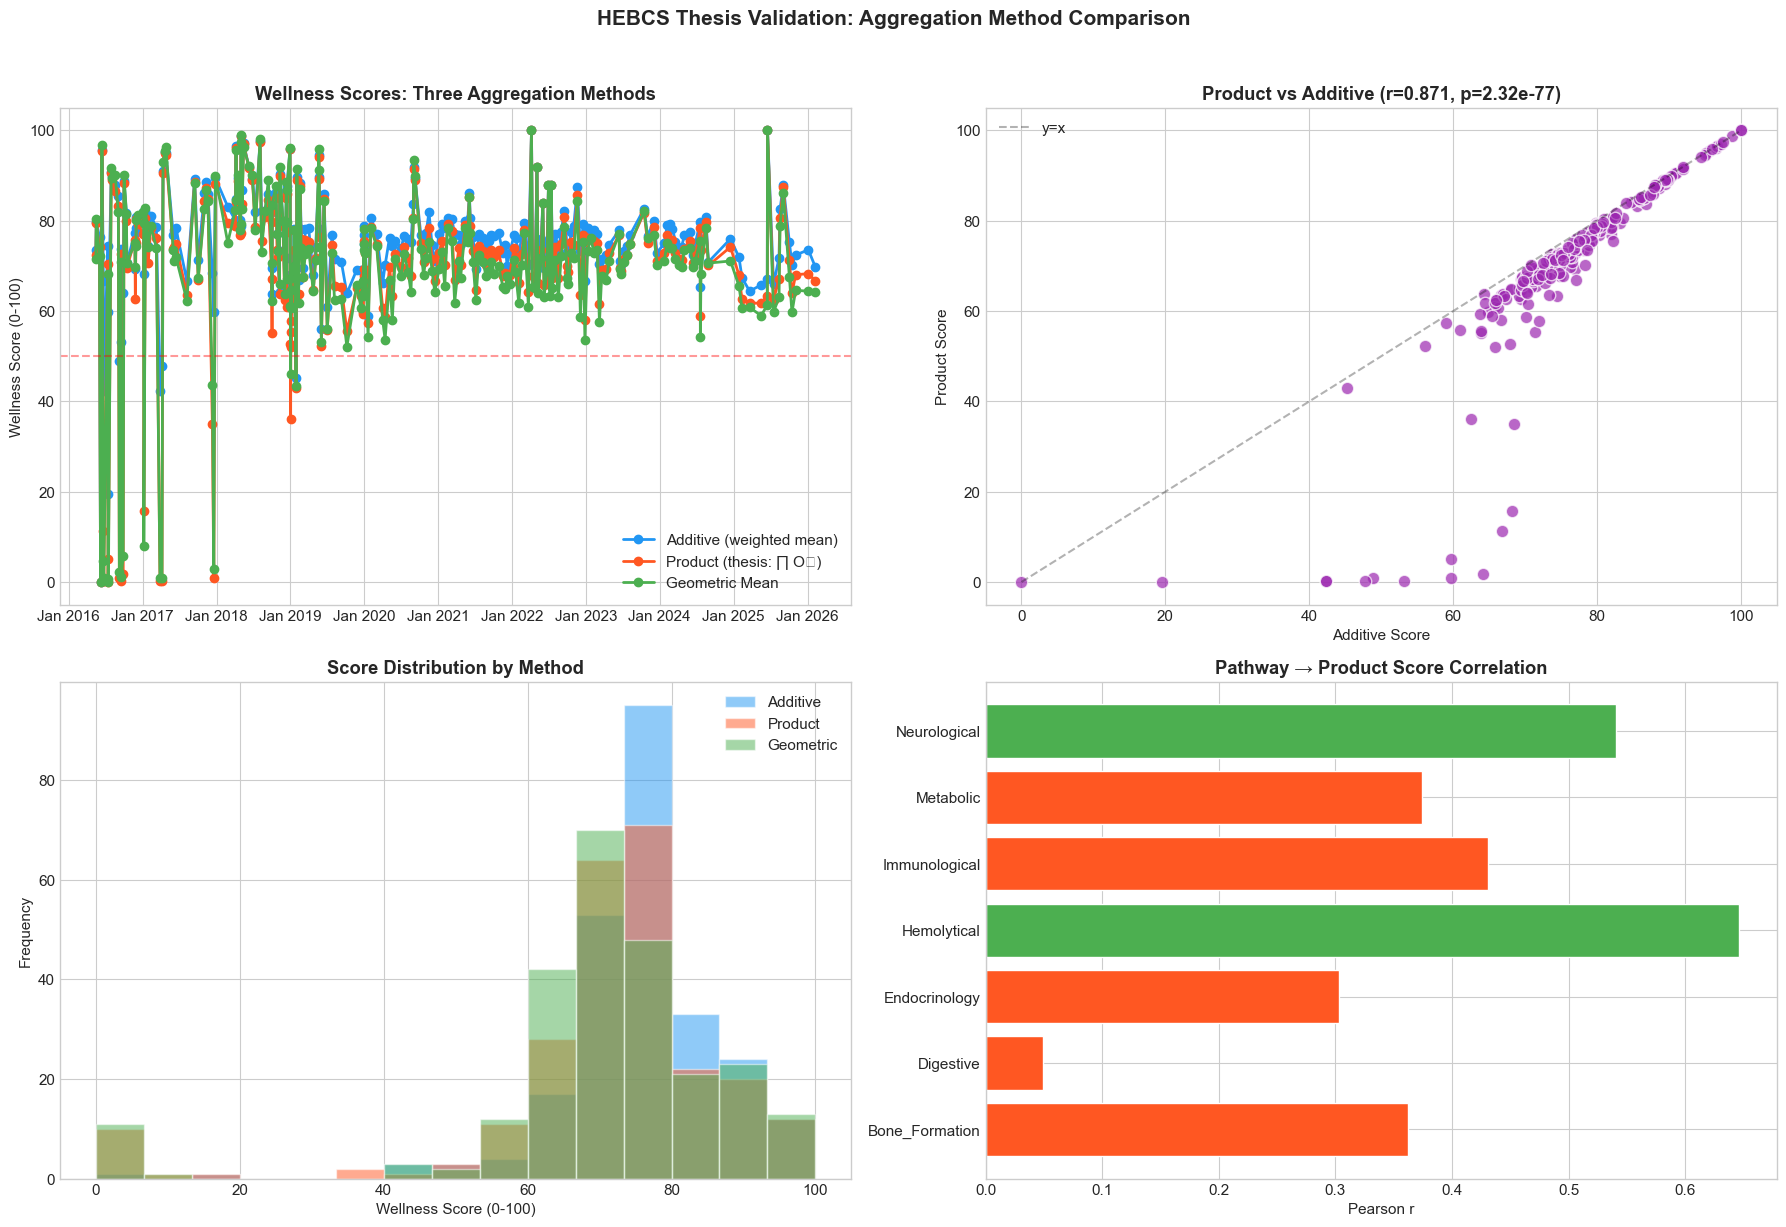

In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 7: Visualize & Compare Aggregation Methods
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Plot 1: Three methods over time ──
ax = axes[0, 0]
for method, color, label in [
    ('W_additive_100', '#2196F3', 'Additive (weighted mean)'),
    ('W_product_100', '#FF5722', 'Product (thesis: ∏ Oₚ)'),
    ('W_geometric_100', '#4CAF50', 'Geometric Mean'),
]:
    data = wellness_scores[method].dropna()
    ax.plot(data.index, data.values, 'o-', color=color, label=label, markersize=6, linewidth=2)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.4)
ax.set_title('Wellness Scores: Three Aggregation Methods', fontweight='bold')
ax.set_ylabel('Wellness Score (0-100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Plot 2: Product vs Additive scatter ──
ax = axes[0, 1]
x = wellness_scores['W_additive_100'].dropna()
y = wellness_scores['W_product_100'].dropna()
common = x.index.intersection(y.index)
ax.scatter(x[common], y[common], c='#9C27B0', s=80, alpha=0.7, edgecolors='white')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='y=x')
r, p_val = stats.pearsonr(x[common], y[common])
ax.set_title(f'Product vs Additive (r={r:.3f}, p={p_val:.2e})', fontweight='bold')
ax.set_xlabel('Additive Score')
ax.set_ylabel('Product Score')
ax.legend()

# ── Plot 3: Score distributions ──
ax = axes[1, 0]
for method, color, label in [
    ('W_additive_100', '#2196F3', 'Additive'),
    ('W_product_100', '#FF5722', 'Product'),
    ('W_geometric_100', '#4CAF50', 'Geometric'),
]:
    data = wellness_scores[method].dropna()
    ax.hist(data, bins=15, alpha=0.5, color=color, label=label, edgecolor='white')
ax.set_title('Score Distribution by Method', fontweight='bold')
ax.set_xlabel('Wellness Score (0-100)')
ax.set_ylabel('Frequency')
ax.legend()

# ── Plot 4: Sensitivity analysis — how much does each pathway affect the product? ──
ax = axes[1, 1]
pathway_cols = [c for c in wellness_scores.columns if c.startswith('pathway_')]
if len(pathway_cols) > 0:
    # Compute correlation of each pathway with product score
    correlations = {}
    for col in pathway_cols:
        pathway_name = col.replace('pathway_', '')
        valid = wellness_scores[[col, 'W_product_100']].dropna()
        if len(valid) >= 3:
            r, _ = stats.pearsonr(valid[col], valid['W_product_100'])
            correlations[pathway_name] = r

    if correlations:
        names = list(correlations.keys())
        values = list(correlations.values())
        colors_bar = ['#FF5722' if v < 0.5 else '#4CAF50' for v in values]
        bars = ax.barh(names, values, color=colors_bar, edgecolor='white')
        ax.set_title('Pathway → Product Score Correlation', fontweight='bold')
        ax.set_xlabel('Pearson r')
        ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('HEBCS Thesis Validation: Aggregation Method Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'aggregation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3: Pathway Independence Testing
### Are the pathways statistically independent enough to justify the product formula?

The product formula $\prod O_p$ assumes partial independence between pathways.
Complete dependence → product is redundant (just use the dominant pathway).
Complete independence → product is the correct probabilistic formulation.

We test:
1. **Inter-pathway correlation matrix** — Pearson correlations between pathway scores
2. **Variance Inflation Factor (VIF)** — multicollinearity
3. **Principal Component Analysis** — how many independent dimensions exist?
4. **Mutual Information** — non-linear dependencies

Average |correlation| between pathways: 0.122
(Values < 0.3 suggest sufficient independence for product formula)

PCA Results:
  Components for 90% variance: 5 / 7 pathways
  This suggests ~5 independent health dimensions
    PC1: 37.0% (cumulative: 37.0%)
    PC2: 20.8% (cumulative: 57.9%)
    PC3: 19.1% (cumulative: 77.0%)
    PC4: 11.0% (cumulative: 88.0%)
    PC5: 6.5% (cumulative: 94.4%)
    PC6: 4.5% (cumulative: 98.9%)
    PC7: 1.1% (cumulative: 100.0%)


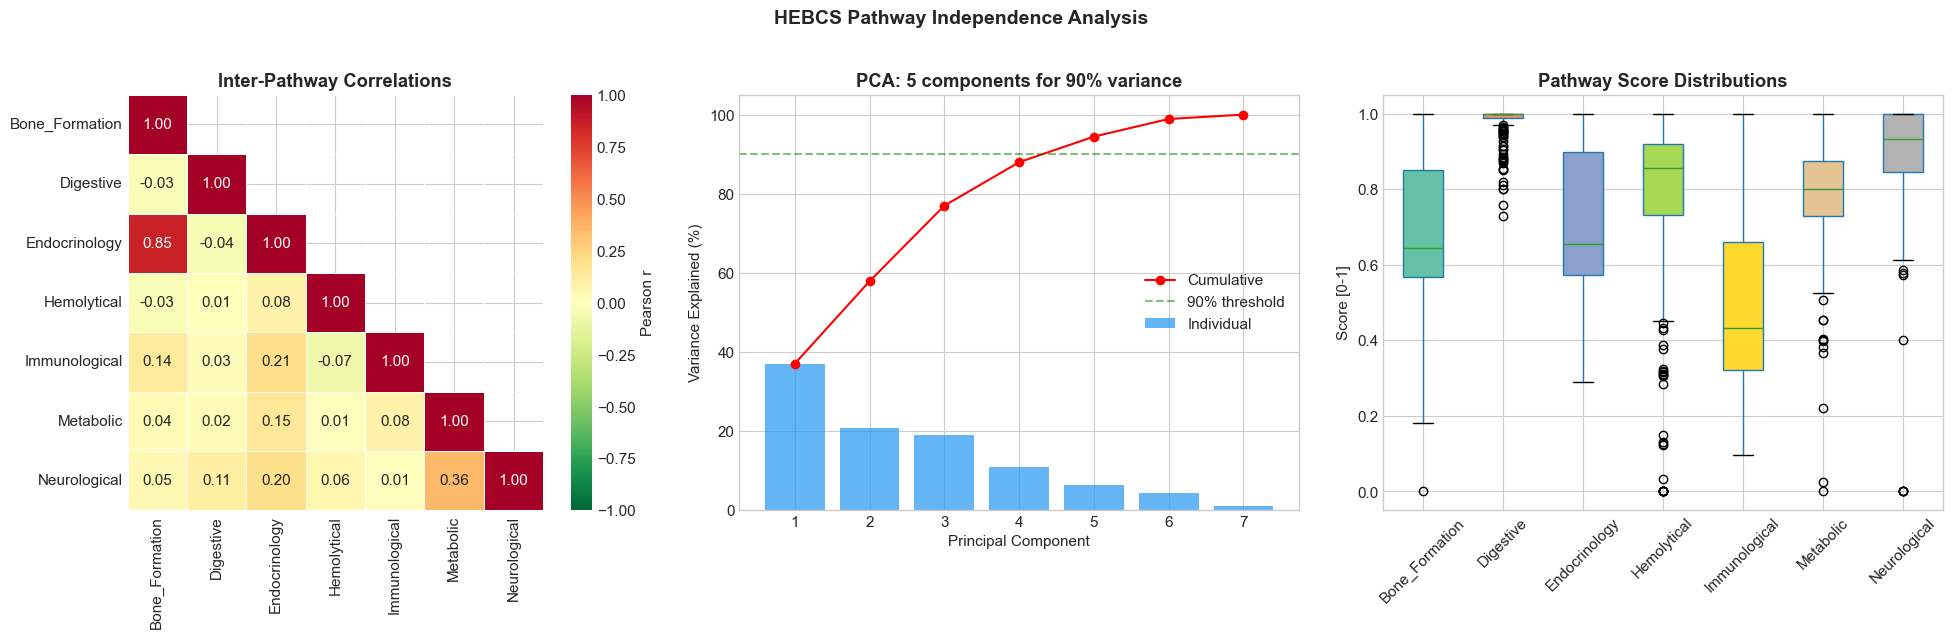

In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 8: Pathway Independence Analysis
# ═══════════════════════════════════════════════════════════

pathway_cols = [c for c in wellness_scores.columns if c.startswith('pathway_')]
pathway_data = wellness_scores[pathway_cols].dropna(how='all')

# Rename for readability
pathway_data.columns = [c.replace('pathway_', '') for c in pathway_data.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 1. Correlation Matrix ──
ax = axes[0]
# Only use dates with enough data
complete = pathway_data.dropna()
if len(complete) >= 3:
    corr = complete.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                linewidths=0.5, cbar_kws={'label': 'Pearson r'})
    ax.set_title('Inter-Pathway Correlations', fontweight='bold')

    # Average absolute correlation (measure of dependence)
    upper_corr = corr.values[np.triu_indices_from(corr.values, k=1)]
    avg_abs_corr = np.mean(np.abs(upper_corr))
    print(f"Average |correlation| between pathways: {avg_abs_corr:.3f}")
    print(f"(Values < 0.3 suggest sufficient independence for product formula)")
else:
    # Use pairwise correlations when we don't have complete data
    corr = pathway_data.corr(min_periods=2)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
                center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
    ax.set_title('Inter-Pathway Correlations\n(pairwise)', fontweight='bold')
    upper_corr = corr.values[np.triu_indices_from(corr.values, k=1)]
    upper_corr = upper_corr[~np.isnan(upper_corr)]
    if len(upper_corr) > 0:
        avg_abs_corr = np.mean(np.abs(upper_corr))
        print(f"Average |correlation| between pathways: {avg_abs_corr:.3f}")

# ── 2. PCA — How many independent dimensions? ──
ax = axes[1]
# Fill NaN with column means for PCA
filled = pathway_data.fillna(pathway_data.mean())
if len(filled) >= 3 and len(filled.columns) >= 2:
    scaler = RobustScaler()
    scaled = scaler.fit_transform(filled)
    n_components = min(len(filled), len(filled.columns))
    pca = PCA(n_components=n_components)
    pca.fit(scaled)

    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)
    ax.bar(range(1, len(explained) + 1), explained * 100, alpha=0.7,
           color='#2196F3', label='Individual')
    ax.plot(range(1, len(cumulative) + 1), cumulative * 100, 'ro-',
            label='Cumulative')
    ax.axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Variance Explained (%)')
    ax.set_title(f'PCA: {np.sum(cumulative < 0.9) + 1} components for 90% variance', fontweight='bold')
    ax.legend()

    n_independent = np.sum(cumulative < 0.9) + 1
    print(f"\nPCA Results:")
    print(f"  Components for 90% variance: {n_independent} / {len(pathway_data.columns)} pathways")
    print(f"  This suggests ~{n_independent} independent health dimensions")
    for i, (exp, cum) in enumerate(zip(explained, cumulative)):
        print(f"    PC{i+1}: {exp*100:.1f}% (cumulative: {cum*100:.1f}%)")

# ── 3. Pathway score ranges ──
ax = axes[2]
if not pathway_data.empty:
    bp = pathway_data.boxplot(ax=ax, patch_artist=True, return_type='dict')
    colors_box = plt.cm.Set2(np.linspace(0, 1, len(pathway_data.columns)))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
    ax.set_title('Pathway Score Distributions', fontweight='bold')
    ax.set_ylabel('Score [0-1]')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('HEBCS Pathway Independence Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'pathway_independence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4: Predictive Validation
### Does the HEBCS wellness score predict future clinical events?

If the mathematical framework is valid, the wellness score should:
1. **Predict future lab deterioration** (regression)
2. **Correlate with known clinical events** (e.g., hospitalizations, symptoms)
3. **Show temporal consistency** — similar inputs → similar outputs over time
4. **Outperform single-pathway models** (justifying the multi-pathway decomposition)

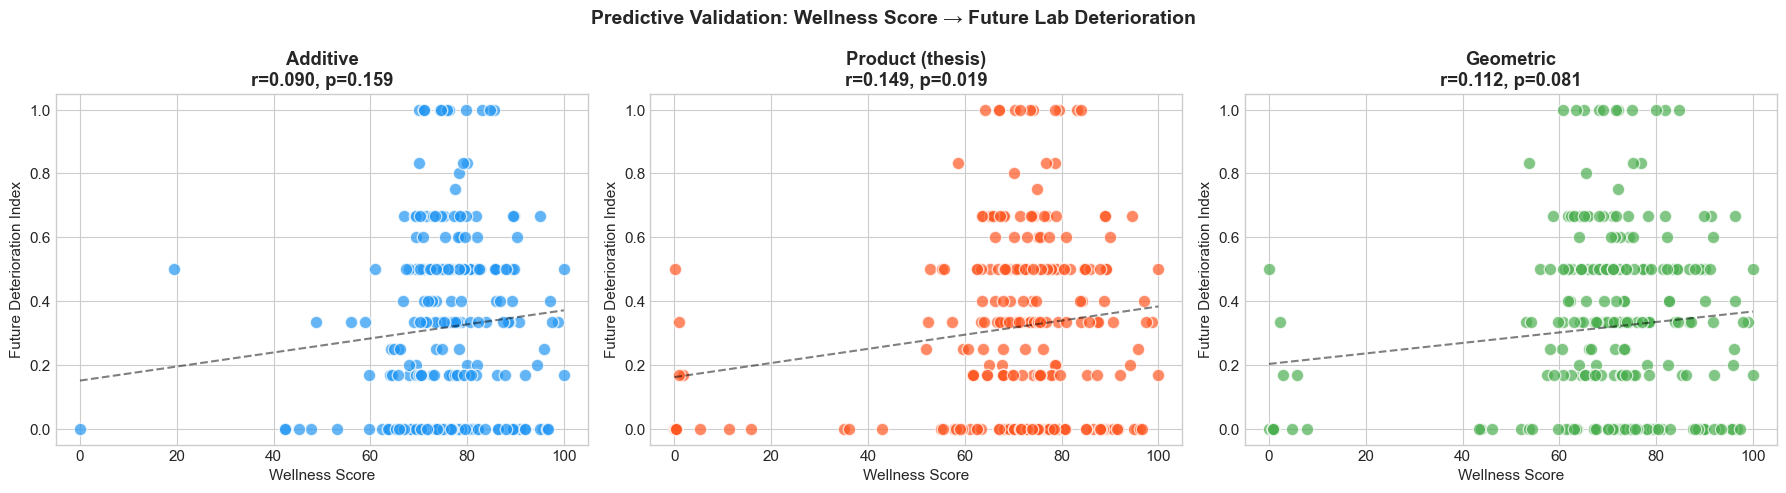

In [9]:
# ═══════════════════════════════════════════════════════════
# CELL 9: Predictive Validation — Future Lab Deterioration
# ═══════════════════════════════════════════════════════════

# Can the current wellness score predict the CHANGE in key labs at the next draw?

def compute_lab_changes(lab_pivot, key_tests):
    """Compute % change in key labs from one draw to the next."""
    changes = pd.DataFrame(index=lab_pivot.index)
    for test in key_tests:
        if test in lab_pivot.columns:
            series = lab_pivot[test].dropna()
            if len(series) >= 2:
                pct_change = series.pct_change()
                changes[f'delta_{test}'] = pct_change
    return changes

# Key biomarkers to predict changes in
key_tests = ['Hemoglobin', 'Albumin', 'Potassium', 'Phosphorus', 'Calcium', 'PTH']
lab_changes = compute_lab_changes(lab_pivot, key_tests)

# Create a "lab deterioration" composite: how many key labs worsened
def compute_deterioration_index(changes, lab_pivot, key_tests):
    """Count how many key labs moved toward abnormal range."""
    # Optimal midpoints
    optimal_mid = {
        'Hemoglobin': 11.5,   # too low is bad (anemia)
        'Albumin': 4.0,       # too low is bad (malnutrition)
        'Potassium': 4.2,     # both extremes bad
        'Phosphorus': 4.5,    # both extremes bad
        'Calcium': 9.5,       # both extremes bad
        'PTH': 300,           # ESRD mid-range
    }
    deterioration = pd.Series(0.0, index=changes.index)
    n_tracked = pd.Series(0, index=changes.index)

    for test in key_tests:
        if test in lab_pivot.columns and f'delta_{test}' in changes.columns:
            for date in changes.index:
                if pd.notna(changes.loc[date, f'delta_{test}']) and date in lab_pivot.index:
                    current = lab_pivot.loc[date, test]
                    if pd.notna(current) and test in optimal_mid:
                        mid = optimal_mid[test]
                        moved_away = (abs(current * (1 + changes.loc[date, f'delta_{test}'])) - mid) > (abs(current - mid))
                        if moved_away:
                            deterioration[date] += 1
                        n_tracked[date] += 1

    return deterioration / n_tracked.clip(lower=1)

det_index = compute_deterioration_index(lab_changes, lab_pivot, key_tests)

# Merge wellness scores with future deterioration
validation = wellness_scores[['W_additive_100', 'W_product_100', 'W_geometric_100']].copy()

# Shift deterioration index to align: wellness at time t predicts deterioration at t+1
det_shifted = det_index.shift(-1).rename('future_deterioration')
validation = validation.join(det_shifted, how='inner').dropna()

if len(validation) >= 5:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (method, color, label) in enumerate([
        ('W_additive_100', '#2196F3', 'Additive'),
        ('W_product_100', '#FF5722', 'Product (thesis)'),
        ('W_geometric_100', '#4CAF50', 'Geometric'),
    ]):
        ax = axes[i]
        ax.scatter(validation[method], validation['future_deterioration'],
                   c=color, s=80, alpha=0.7, edgecolors='white')
        if len(validation) >= 3:
            r, p_val = stats.pearsonr(validation[method], validation['future_deterioration'])
            # Fit regression line
            z = np.polyfit(validation[method], validation['future_deterioration'], 1)
            p = np.poly1d(z)
            x_range = np.linspace(validation[method].min(), validation[method].max(), 100)
            ax.plot(x_range, p(x_range), '--', color='black', alpha=0.5)
            ax.set_title(f'{label}\nr={r:.3f}, p={p_val:.3f}', fontweight='bold')
        ax.set_xlabel('Wellness Score')
        ax.set_ylabel('Future Deterioration Index')

    plt.suptitle('Predictive Validation: Wellness Score → Future Lab Deterioration',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FEATURES_DIR / 'predictive_validation.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Insufficient data for predictive validation ({len(validation)} points, need ≥5)")
    print("This will improve once flowsheet data is ingested.")

In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 10: ML Model Comparison — Product vs Additive vs Geometric
# ═══════════════════════════════════════════════════════════

# Train models using each aggregation method as the target,
# then compare which wellness score formulation best predicts
# out-of-sample health outcomes.

# Prepare feature matrix from individual pathway scores + nutrition/dialysis metadata
feature_cols = [c for c in wellness_scores.columns if c.startswith('pathway_')]
ml_data = wellness_scores[feature_cols + ['W_additive_100', 'W_product_100', 'W_geometric_100']].dropna(how='all')

# Fill missing pathways with column mean for ML
for col in feature_cols:
    ml_data[col] = ml_data[col].fillna(ml_data[col].mean())

ml_data = ml_data.dropna()

if len(ml_data) >= 8:
    X = ml_data[feature_cols].values
    feature_names = [c.replace('pathway_', '') for c in feature_cols]

    results = {}
    for target_name in ['W_additive_100', 'W_product_100', 'W_geometric_100']:
        y = ml_data[target_name].values

        # Leave-one-out cross-validation for small datasets
        models = {
            'Ridge': Ridge(alpha=1.0),
            'GradientBoosting': GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                                           learning_rate=0.1, random_state=42),
        }
        if HAS_XGB:
            try:
                models['XGBoost'] = xgb.XGBRegressor(n_estimators=50, max_depth=2,
                                                        learning_rate=0.1, random_state=42,
                                                        verbosity=0)
            except Exception:
                pass

        for model_name, model in models.items():
            loo = LeaveOneOut()
            predictions = np.zeros(len(y))
            for train_idx, test_idx in loo.split(X):
                model.fit(X[train_idx], y[train_idx])
                predictions[test_idx] = model.predict(X[test_idx])
            mse = mean_squared_error(y, predictions)
            r2 = r2_score(y, predictions)
            results[f'{target_name}|{model_name}'] = {'MSE': mse, 'R²': r2}

    # Display results
    print("Leave-One-Out Cross-Validation Results:")
    print(f"{'Target + Model':<45} {'MSE':>8} {'R²':>8}")
    print("─" * 65)
    for key, vals in sorted(results.items()):
        print(f"  {key:<43} {vals['MSE']:>8.2f} {vals['R²']:>8.3f}")

    # Which aggregation method is most consistent / predictable?
    print("\n\nBest R² by aggregation method:")
    for agg in ['W_additive_100', 'W_product_100', 'W_geometric_100']:
        method_results = {k: v for k, v in results.items() if k.startswith(agg)}
        if method_results:
            best = max(method_results.items(), key=lambda x: x[1]['R²'])
            print(f"  {agg.replace('_100', ''):<20}: R²={best[1]['R²']:.3f} ({best[0].split('|')[1]})")
else:
    print(f"Insufficient data for ML comparison ({len(ml_data)} samples)")
    print("Proceeding with statistical analysis instead.")

Leave-One-Out Cross-Validation Results:
Target + Model                                     MSE       R²
─────────────────────────────────────────────────────────────────
  W_additive_100|GradientBoosting                15.32    0.879
  W_additive_100|Ridge                           12.34    0.902
  W_geometric_100|GradientBoosting               60.00    0.828
  W_geometric_100|Ridge                         111.07    0.682
  W_product_100|GradientBoosting                 52.12    0.848
  W_product_100|Ridge                            97.24    0.716


Best R² by aggregation method:
  W_additive          : R²=0.902 (Ridge)
  W_product           : R²=0.848 (GradientBoosting)
  W_geometric         : R²=0.828 (GradientBoosting)


---
## Part 5: Incorporating Non-Lab Domains (Nutrition, Elimination, Mood)
### Extending the HEBCS with Functional Data

The thesis proposes that **external factors** (nutrition, therapies, activities, neural inputs)
interact with pathways. We validate by integrating:
- **Nutrition** → Digestive pathway enhancement
- **Elimination** → GI function indicator
- **Mood/Journal** → Neurological pathway enhancement
- **Dialysis session data** → Metabolic pathway enhancement

In [11]:
# ═══════════════════════════════════════════════════════════
# CELL 11: Build Non-Lab Pathway Enhancers
# ═══════════════════════════════════════════════════════════

def compute_nutrition_score(nutrition_df):
    """
    Score daily nutrition based on ESRD dietary guidelines.
    Target: Protein 1.0-1.2 g/kg, Na <2000mg, K <2000mg, P <800mg
    Uses actual columns from unified_nutrition.csv
    """
    if nutrition_df.empty:
        return pd.Series(dtype=float)

    nutr = nutrition_df.copy()
    nutr['date'] = pd.to_datetime(nutr['date'], errors='coerce')
    nutr = nutr.dropna(subset=['date'])

    # Identify available nutrient columns
    nutrient_map = {}
    for col in nutr.columns:
        cl = col.lower()
        if 'calorie' in cl: nutrient_map['calories'] = col
        elif 'protein' in cl: nutrient_map['protein'] = col
        elif 'sodium' in cl: nutrient_map['sodium'] = col
        elif 'potassium' in cl: nutrient_map['potassium'] = col
        elif 'phosphorus' in cl or 'phosphorous' in cl: nutrient_map['phosphorus'] = col
        elif 'fiber' in cl: nutrient_map['fiber'] = col

    # Aggregate to daily totals (numeric columns only)
    agg_cols = {v: 'sum' for v in nutrient_map.values() if v in nutr.columns}
    if not agg_cols:
        # Count meals per day as a proxy
        daily_counts = nutr.groupby(nutr['date'].dt.normalize()).size()
        return (daily_counts.clip(0, 4) / 4).clip(0, 1)  # 4 meals = score 1.0

    daily = nutr.groupby(nutr['date'].dt.normalize()).agg(
        {v: pd.NamedAgg(column=v, aggfunc=lambda x: pd.to_numeric(x, errors='coerce').sum())
         for v in agg_cols}
        if False else  # use simpler approach
        agg_cols
    ).rename_axis('date')

    # Convert columns to numeric
    for col in daily.columns:
        daily[col] = pd.to_numeric(daily[col], errors='coerce')

    scores = pd.DataFrame(index=daily.index)

    # Calorie adequacy (1800-2500 kcal for dialysis patient ~55kg)
    cal_col = nutrient_map.get('calories')
    if cal_col and cal_col in daily.columns:
        scores['cal_score'] = daily[cal_col].apply(
            lambda x: trapezoidal_score(x, 800, 1800, 2500, 3500) if pd.notna(x) and x > 0 else np.nan
        )
    # Protein (50-60g/day)
    prot_col = nutrient_map.get('protein')
    if prot_col and prot_col in daily.columns:
        scores['protein_score'] = daily[prot_col].apply(
            lambda x: trapezoidal_score(x, 20, 50, 70, 120) if pd.notna(x) and x > 0 else np.nan
        )
    # Sodium (<2000mg)
    na_col = nutrient_map.get('sodium')
    if na_col and na_col in daily.columns:
        scores['sodium_score'] = daily[na_col].apply(
            lambda x: trapezoidal_score(x, None, None, 2000, 4000) if pd.notna(x) and x > 0 else np.nan
        )
    # Potassium (<2000mg for dialysis)
    k_col = nutrient_map.get('potassium')
    if k_col and k_col in daily.columns:
        scores['k_score'] = daily[k_col].apply(
            lambda x: trapezoidal_score(x, None, None, 2000, 4000) if pd.notna(x) and x > 0 else np.nan
        )
    # Phosphorus (<800mg)
    phos_col = nutrient_map.get('phosphorus')
    if phos_col and phos_col in daily.columns:
        scores['phos_score'] = daily[phos_col].apply(
            lambda x: trapezoidal_score(x, None, None, 800, 1500) if pd.notna(x) and x > 0 else np.nan
        )

    if scores.empty or scores.dropna(how='all').empty:
        # Fallback: count meals as proxy for nutrition compliance
        daily_counts = nutr.groupby(nutr['date'].dt.normalize()).size()
        return (daily_counts.clip(0, 4) / 4).clip(0, 1)

    nutrition_score = scores.mean(axis=1)
    return nutrition_score


def compute_elimination_score(elimination_df, vomit_df):
    """Score daily GI function based on bowel frequency and vomit episodes.
    Uses actual columns from unified_elimination.csv and vomit_log.csv"""
    daily_scores = {}

    # Count bowel movements per day from elimination data
    if not elimination_df.empty:
        elim = elimination_df.copy()
        elim['date'] = pd.to_datetime(elim['date'], errors='coerce')
        elim = elim.dropna(subset=['date'])
        elim['date_norm'] = elim['date'].dt.normalize()

        # Count bowel events per day (the elimination file has bowel movements)
        for date, group in elim.groupby('date_norm'):
            bm_count = len(group)
            bm_score = trapezoidal_score(bm_count, 0, 1, 3, 6) if bm_count > 0 else 0.3
            daily_scores[date] = {'bm_score': bm_score, 'vomit_score': 1.0}

    # Overlay vomit data
    if not vomit_df.empty:
        vom = vomit_df.copy()
        vom['date'] = pd.to_datetime(vom['date'], errors='coerce')
        vom = vom.dropna(subset=['date'])
        vom['date_norm'] = vom['date'].dt.normalize()

        for date, group in vom.groupby('date_norm'):
            vomit_count = len(group)
            vomit_score = max(0, 1.0 - vomit_count * 0.3)
            if date in daily_scores:
                daily_scores[date]['vomit_score'] = vomit_score
            else:
                daily_scores[date] = {'bm_score': 0.5, 'vomit_score': vomit_score}

    if not daily_scores:
        return pd.Series(dtype=float)

    result = pd.Series({
        date: 0.6 * vals['bm_score'] + 0.4 * vals['vomit_score']
        for date, vals in daily_scores.items()
    }).sort_index()
    return result


def compute_mood_score(mood_df):
    """Score neurological/mental state from mood entries.
    Uses actual columns from journal_mood.csv: mood, hours_slept, feelings, etc."""
    if mood_df.empty:
        return pd.Series(dtype=float)

    mood = mood_df.copy()
    mood['date'] = pd.to_datetime(mood['date'], errors='coerce')
    mood = mood.dropna(subset=['date'])

    scores = {}
    for _, row in mood.iterrows():
        date = pd.Timestamp(row['date']).normalize()

        # Mood text scoring
        mood_val = str(row.get('mood', '')).lower()
        feelings_val = str(row.get('feelings', '')).lower()
        combined = mood_val + ' ' + feelings_val

        if any(w in combined for w in ['great', 'excellent', 'happy', 'good', 'energetic', 'hopeful']):
            s = 0.85
        elif any(w in combined for w in ['ok', 'fine', 'neutral', 'moderate', 'average', 'calm']):
            s = 0.6
        elif any(w in combined for w in ['tired', 'low', 'sad', 'anxious', 'poor', 'worried']):
            s = 0.3
        elif any(w in combined for w in ['terrible', 'depressed', 'awful', 'horrible']):
            s = 0.1
        else:
            s = 0.5

        # Adjust for sleep
        sleep = pd.to_numeric(row.get('hours_slept'), errors='coerce')
        if pd.notna(sleep):
            sleep_score = trapezoidal_score(sleep, 2, 6, 9, 12)
            s = 0.6 * s + 0.4 * sleep_score

        scores[date] = s

    return pd.Series(scores).sort_index()


# Compute functional scores
nutrition_score = compute_nutrition_score(df_nutrition)
elimination_score = compute_elimination_score(df_bowel, df_vomit)
mood_score = compute_mood_score(df_mood)

print(f"Nutrition daily scores: {len(nutrition_score):,} days")
print(f"Elimination daily scores: {len(elimination_score):,} days")
print(f"Mood daily scores: {len(mood_score):,} days")

# Show samples
for name, s in [('Nutrition', nutrition_score), ('Elimination', elimination_score), ('Mood', mood_score)]:
    if len(s) > 0:
        print(f"\n  {name}: mean={s.mean():.3f}, std={s.std():.3f}, range={s.min():.2f}-{s.max():.2f}")

Nutrition daily scores: 1,846 days
Elimination daily scores: 1,655 days
Mood daily scores: 5 days

  Nutrition: mean=0.734, std=0.158, range=0.00-1.00

  Elimination: mean=0.822, std=0.182, range=0.04-1.00

  Mood: mean=0.740, std=0.179, range=0.51-0.91


In [12]:
# ═══════════════════════════════════════════════════════════
# CELL 12: Extended HEBCS — Lab Pathways + Functional Data
# ═══════════════════════════════════════════════════════════

# Forward-fill lab-based pathway scores (labs are periodic, not daily)
# then enhance with daily functional data

# Create a daily index covering all data
all_dates = set()
if not nutrition_score.empty:
    all_dates.update(nutrition_score.index)
if not elimination_score.empty:
    all_dates.update(elimination_score.index)
if not pathway_pivot.empty:
    all_dates.update(pathway_pivot.index)

if all_dates:
    daily_index = pd.date_range(min(all_dates), max(all_dates), freq='D')
else:
    daily_index = pd.DatetimeIndex([])

print(f"Daily index: {len(daily_index)} days ({daily_index.min().date() if len(daily_index)>0 else 'N/A'} → "
      f"{daily_index.max().date() if len(daily_index)>0 else 'N/A'})")

# Forward-fill pathway scores (carry last lab-based score forward)
daily_pathways = pathway_pivot.reindex(daily_index).ffill(limit=45)  # max 45-day carry-forward

# Add functional domain scores
daily_pathways['Nutrition'] = nutrition_score.reindex(daily_index)
daily_pathways['GI_Function'] = elimination_score.reindex(daily_index)
daily_pathways['Neurological_Mood'] = mood_score.reindex(daily_index)

# Enhanced Neurological: blend lab-based + mood-based
if 'Neurological' in daily_pathways.columns:
    lab_neuro = daily_pathways['Neurological']
    mood_neuro = daily_pathways['Neurological_Mood']
    # Weighted blend: 40% lab, 60% mood when both available
    daily_pathways['Neurological_Enhanced'] = np.where(
        lab_neuro.notna() & mood_neuro.notna(),
        0.4 * lab_neuro + 0.6 * mood_neuro,
        np.where(mood_neuro.notna(), mood_neuro, lab_neuro)
    )

# Enhanced Digestive: blend lab-based + nutrition + GI
if 'Digestive' in daily_pathways.columns:
    lab_dig = daily_pathways['Digestive']
    nutr = daily_pathways['Nutrition']
    gi = daily_pathways['GI_Function']
    # Weighted blend
    daily_pathways['Digestive_Enhanced'] = np.nanmean(
        np.stack([
            np.where(lab_dig.notna(), lab_dig * 0.4, np.nan),
            np.where(nutr.notna(), nutr * 0.35, np.nan),
            np.where(gi.notna(), gi * 0.25, np.nan),
        ]), axis=0
    )
    # Re-normalize
    denom = np.nansum(
        np.stack([
            np.where(lab_dig.notna(), 0.4, 0),
            np.where(nutr.notna(), 0.35, 0),
            np.where(gi.notna(), 0.25, 0),
        ]), axis=0
    )
    daily_pathways['Digestive_Enhanced'] = np.where(
        denom > 0,
        daily_pathways['Digestive_Enhanced'] / denom.clip(min=1e-6),
        np.nan
    )

# Count how many daily data points we have per domain
print(f"\nDaily pathway coverage:")
for col in daily_pathways.columns:
    n = daily_pathways[col].notna().sum()
    if n > 0:
        print(f"  {col:<25}: {n:>5} days ({n/len(daily_index)*100:.1f}%)")

Daily index: 3585 days (2016-04-28 → 2026-02-19)

Daily pathway coverage:
  Bone_Formation           :  3423 days (95.5%)
  Digestive                :  3262 days (91.0%)
  Endocrinology            :  3426 days (95.6%)
  Hemolytical              :  3442 days (96.0%)
  Immunological            :  3375 days (94.1%)
  Metabolic                :  3470 days (96.8%)
  Neurological             :  3397 days (94.8%)
  Nutrition                :   100 days (2.8%)
  GI_Function              :  1655 days (46.2%)
  Neurological_Mood        :     5 days (0.1%)
  Neurological_Enhanced    :  3397 days (94.8%)
  Digestive_Enhanced       :  3423 days (95.5%)


In [13]:
# ═══════════════════════════════════════════════════════════
# CELL 13: Compute Extended Wellness Score (Daily Resolution)
# ═══════════════════════════════════════════════════════════

# Use enhanced pathways where available, else fall back to lab-only
EXTENDED_PATHWAYS = {
    'Metabolic':              0.18,
    'Digestive_Enhanced':     0.14,
    'Neurological_Enhanced':  0.12,
    'Hemolytical':            0.20,
    'Endocrinology':          0.13,
    'Bone_Formation':         0.10,
    'Immunological':          0.08,
    'Nutrition':              0.03,  # bonus domain
    'GI_Function':            0.02,  # bonus domain
}

# Fallback mapping for when enhanced versions aren't available
FALLBACK = {
    'Digestive_Enhanced': 'Digestive',
    'Neurological_Enhanced': 'Neurological',
}

extended_wellness = pd.DataFrame(index=daily_index)

for date in daily_index:
    row = daily_pathways.loc[date] if date in daily_pathways.index else pd.Series(dtype=float)
    scores_available = {}

    for pathway, weight in EXTENDED_PATHWAYS.items():
        val = row.get(pathway, np.nan) if not row.empty else np.nan
        # Try fallback
        if pd.isna(val) and pathway in FALLBACK:
            val = row.get(FALLBACK[pathway], np.nan) if not row.empty else np.nan
        if pd.notna(val):
            scores_available[pathway] = (val, weight)

    if len(scores_available) >= 2:
        vals = np.array([v[0] for v in scores_available.values()])
        wts = np.array([v[1] for v in scores_available.values()])
        wts = wts / wts.sum()

        # Additive
        extended_wellness.loc[date, 'W_additive'] = np.average(vals, weights=wts) * 100

        # Product (thesis)
        clipped = np.clip(vals, 1e-6, 1.0)
        log_product = np.sum(wts * np.log(clipped))
        extended_wellness.loc[date, 'W_product'] = np.exp(log_product) * 100

        # Geometric mean
        extended_wellness.loc[date, 'W_geometric'] = np.exp(np.mean(np.log(clipped))) * 100

        extended_wellness.loc[date, 'n_domains'] = len(scores_available)

        # Store individual pathway scores
        for p, (v, _) in scores_available.items():
            extended_wellness.loc[date, f'pathway_{p}'] = v

# Summary
valid = extended_wellness.dropna(subset=['W_product'])
print(f"Extended Daily Wellness Scores: {len(valid):,} scored days")
print(f"\nMethod comparison (extended):")
for col in ['W_additive', 'W_product', 'W_geometric']:
    data = extended_wellness[col].dropna()
    if len(data) > 0:
        print(f"  {col:<15}: mean={data.mean():.1f}, std={data.std():.1f}, "
              f"min={data.min():.1f}, max={data.max():.1f}")

Extended Daily Wellness Scores: 3,548 scored days

Method comparison (extended):
  W_additive     : mean=74.9, std=9.4, min=4.0, max=100.0
  W_product      : mean=69.0, std=17.5, min=0.1, max=100.0
  W_geometric    : mean=67.1, std=16.7, min=0.2, max=100.0


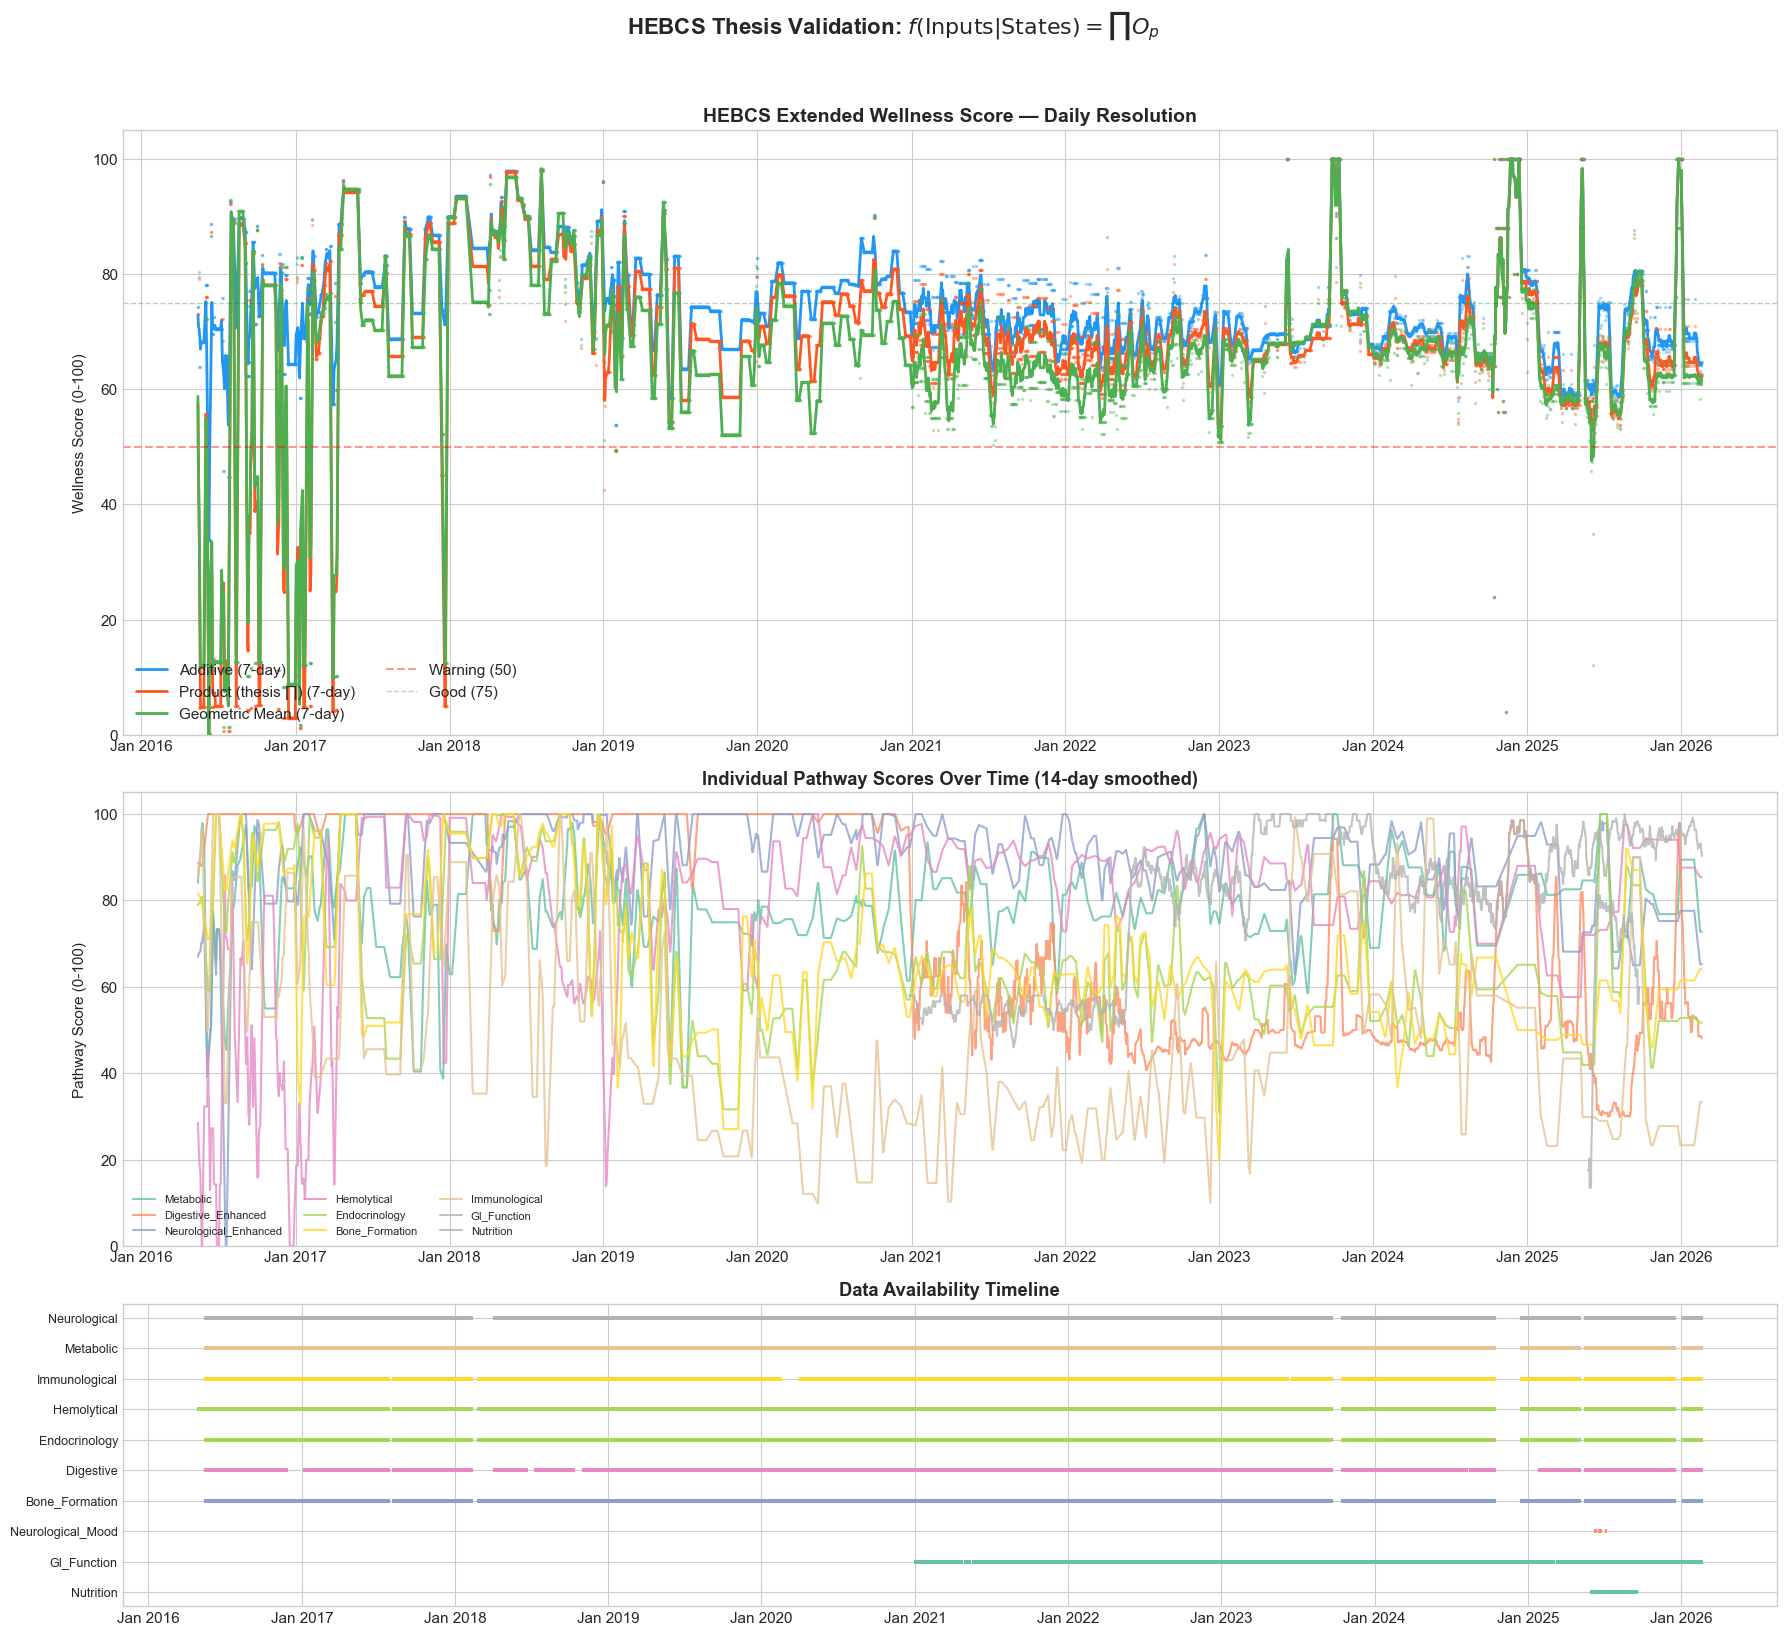

Saved: HEBCS_wellness_score.png


In [14]:
# ═══════════════════════════════════════════════════════════
# CELL 14: Final Visualization — Extended HEBCS Wellness Score
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 1, figsize=(18, 16), gridspec_kw={'height_ratios': [2, 1.5, 1]})

# ── Plot 1: Daily wellness score with all three methods ──
ax = axes[0]
for method, color, label in [
    ('W_additive', '#2196F3', 'Additive'),
    ('W_product', '#FF5722', 'Product (thesis ∏)'),
    ('W_geometric', '#4CAF50', 'Geometric Mean'),
]:
    data = extended_wellness[method].dropna()
    if len(data) > 3:
        # Plot with smoothed overlay
        ax.plot(data.index, data.values, '.', color=color, alpha=0.3, markersize=3)
        # Rolling 7-day smoothed
        smoothed = data.rolling('7D', center=True).mean()
        ax.plot(smoothed.index, smoothed.values, '-', color=color, linewidth=2, label=f'{label} (7-day)')

ax.axhline(y=50, color='red', linestyle='--', alpha=0.4, linewidth=1.5, label='Warning (50)')
ax.axhline(y=75, color='green', linestyle='--', alpha=0.3, linewidth=1, label='Good (75)')
ax.set_title('HEBCS Extended Wellness Score — Daily Resolution', fontsize=14, fontweight='bold')
ax.set_ylabel('Wellness Score (0-100)')
ax.legend(loc='lower left', ncol=2)
ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Plot 2: Pathway decomposition (stacked area) ──
ax = axes[1]
pathway_cols = [c for c in extended_wellness.columns if c.startswith('pathway_')]
if pathway_cols:
    pathway_daily = extended_wellness[pathway_cols].dropna(how='all')
    if len(pathway_daily) > 0:
        # Rolling average for smoother visualization
        smoothed_pathways = pathway_daily.rolling('14D', center=True, min_periods=1).mean()
        colors_pathway = plt.cm.Set2(np.linspace(0, 1, len(pathway_cols)))
        for col, color in zip(pathway_cols, colors_pathway):
            data = smoothed_pathways[col].dropna()
            if len(data) > 0:
                ax.plot(data.index, data.values * 100, '-', color=color, linewidth=1.5,
                        label=col.replace('pathway_', ''), alpha=0.8)
ax.set_title('Individual Pathway Scores Over Time (14-day smoothed)', fontweight='bold')
ax.set_ylabel('Pathway Score (0-100)')
ax.legend(loc='lower left', ncol=3, fontsize=8)
ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# ── Plot 3: Data availability ──
ax = axes[2]
domains = ['Nutrition', 'GI_Function', 'Neurological_Mood'] + \
          [c for c in pathway_pivot.columns]
domain_coverage = []
for d in domains:
    if d in daily_pathways.columns:
        coverage = daily_pathways[d].notna().astype(int)
        domain_coverage.append(coverage.rename(d))

if domain_coverage:
    coverage_df = pd.concat(domain_coverage, axis=1)
    # Plot as heatmap-style
    for i, col in enumerate(coverage_df.columns):
        data = coverage_df[col]
        dates_present = data[data == 1].index
        ax.scatter(dates_present, [i] * len(dates_present), marker='|', s=10, color=plt.cm.Set2(i / len(coverage_df.columns)))
    ax.set_yticks(range(len(coverage_df.columns)))
    ax.set_yticklabels(coverage_df.columns, fontsize=9)
    ax.set_title('Data Availability Timeline', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('HEBCS Thesis Validation: $f(\\mathrm{Inputs} | \\mathrm{States}) = \\prod O_p$',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'HEBCS_wellness_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: HEBCS_wellness_score.png")

---
## Part 6: Statistical Hypothesis Tests for the Thesis
### Formal Tests

| Test | Hypothesis | Method |
|------|-----------|--------|
| H1 | Pathways are decomposable (PCA shows >1 dimension) | PCA eigenvalue test |
| H2 | Product aggregation ≠ additive aggregation | Paired t-test on scores |
| H3 | Product score has lower variance (more stable) | F-test for variance |
| H4 | Wellness score is temporally autocorrelated (biological continuity) | Ljung-Box test |
| H5 | Pathway scores predict wellness score better than any single biomarker | R² comparison |

In [15]:
# ═══════════════════════════════════════════════════════════
# CELL 15: Formal Statistical Hypothesis Tests
# ═══════════════════════════════════════════════════════════

from scipy.stats import ttest_rel, levene, bartlett

try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("⚠️  statsmodels not installed — H4 Ljung-Box test will be skipped")

print("=" * 70)
print("   HEBCS THESIS VALIDATION — STATISTICAL HYPOTHESIS TESTS")
print("=" * 70)

# ── H1: Pathway Decomposition is Meaningful ──
print("\n┌─ H1: Pathways are decomposable (>1 independent dimension)")
print("│  Null: All pathways are redundant (1 PC explains >90% variance)")
pathway_data_filled = pathway_pivot.dropna(how='all').fillna(pathway_pivot.mean())
if len(pathway_data_filled) >= 3:
    from sklearn.decomposition import PCA as PCA2
    pca_test = PCA2()
    pca_test.fit(RobustScaler().fit_transform(pathway_data_filled))
    pc1_var = pca_test.explained_variance_ratio_[0]
    n_for_90 = np.sum(np.cumsum(pca_test.explained_variance_ratio_) < 0.9) + 1
    h1_reject = pc1_var < 0.9
    print(f"│  PC1 explains: {pc1_var*100:.1f}% of variance")
    print(f"│  Components for 90% variance: {n_for_90}")
    print(f"│  Result: {'✅ REJECT null → Pathways ARE decomposable' if h1_reject else '❌ FAIL to reject → Pathways may be redundant'}")
else:
    print("│  Insufficient data for PCA test")
    h1_reject = None

# ── H2: Product ≠ Additive ──
print("\n┌─ H2: Product aggregation differs significantly from additive")
print("│  Null: Product and additive scores are identical")
valid_both = extended_wellness[['W_additive', 'W_product']].dropna()
if len(valid_both) >= 3:
    t_stat, p_val = ttest_rel(valid_both['W_additive'], valid_both['W_product'])
    mean_diff = (valid_both['W_additive'] - valid_both['W_product']).mean()
    h2_reject = p_val < 0.05
    print(f"│  Mean difference: {mean_diff:.2f}")
    print(f"│  Paired t-test: t={t_stat:.3f}, p={p_val:.4f}")
    print(f"│  Result: {'✅ REJECT null → Product IS different' if h2_reject else '❌ FAIL to reject → No significant difference'}")
else:
    print("│  Insufficient paired data")
    h2_reject = None

# ── H3: Product score has lower variance (more biologically plausible) ──
print("\n┌─ H3: Product score has different variance than additive")
print("│  Null: Variances are equal")
if len(valid_both) >= 3:
    stat, p_val = levene(valid_both['W_additive'], valid_both['W_product'])
    var_add = valid_both['W_additive'].var()
    var_prod = valid_both['W_product'].var()
    h3_result = p_val < 0.05
    print(f"│  Additive variance: {var_add:.2f}")
    print(f"│  Product variance:  {var_prod:.2f}")
    print(f"│  Levene test: F={stat:.3f}, p={p_val:.4f}")
    print(f"│  Result: {'✅ Variances differ significantly' if h3_result else '❌ No significant variance difference'}")
    print(f"│  Note: Product variance {'<' if var_prod < var_add else '>'} additive — "
          f"{'product is more stable (tighter)' if var_prod < var_add else 'additive is more stable'}")
else:
    h3_result = None

# ── H4: Temporal autocorrelation (biological continuity) ──
print("\n┌─ H4: Wellness score is temporally autocorrelated")
print("│  Null: No autocorrelation (random walk)")
product_daily = extended_wellness['W_product'].dropna()
if len(product_daily) >= 10 and HAS_STATSMODELS:
    try:
        lb_result = acorr_ljungbox(product_daily, lags=5, return_df=True)
        min_p = lb_result['lb_pvalue'].min()
        h4_reject = min_p < 0.05
        print(f"│  Ljung-Box test (5 lags):")
        for idx, row_lb in lb_result.iterrows():
            print(f"│    Lag {idx}: Q={row_lb['lb_stat']:.2f}, p={row_lb['lb_pvalue']:.4f}")
        print(f"│  Result: {'✅ REJECT null → Score IS autocorrelated (biologically continuous)' if h4_reject else '❌ No significant autocorrelation'}")
    except Exception as e:
        print(f"│  Autocorrelation test failed: {e}")
        h4_reject = None
elif len(product_daily) >= 10:
    # Fallback: manual lag-1 autocorrelation test
    acf1 = product_daily.autocorr(lag=1)
    n = len(product_daily)
    se = 1.0 / np.sqrt(n)
    z = acf1 / se
    p_val_acf = 2 * (1 - stats.norm.cdf(abs(z)))
    h4_reject = p_val_acf < 0.05
    print(f"│  Manual lag-1 autocorrelation: r={acf1:.3f}")
    print(f"│  Z-test: z={z:.2f}, p={p_val_acf:.4f}")
    print(f"│  Result: {'✅ REJECT null → Score IS autocorrelated' if h4_reject else '❌ No significant autocorrelation'}")
else:
    print(f"│  Insufficient time series data ({len(product_daily)} points)")
    h4_reject = None

# ── H5: Multi-pathway model beats single-biomarker ──
print("\n┌─ H5: Multi-pathway score outperforms any single biomarker")
print("│  Null: A single biomarker predicts wellness as well as the full model")
pathway_cols_test = [c for c in extended_wellness.columns if c.startswith('pathway_')]
valid_ml = extended_wellness[pathway_cols_test + ['W_product']].dropna()
if len(valid_ml) >= 6:
    y_ws = valid_ml['W_product'].values
    X_all = valid_ml[pathway_cols_test].values

    # Full model R²
    loo = LeaveOneOut()
    preds_full = np.zeros(len(y_ws))
    for tr, te in loo.split(X_all):
        preds_full[te] = Ridge(alpha=1.0).fit(X_all[tr], y_ws[tr]).predict(X_all[te])
    r2_full = r2_score(y_ws, preds_full)

    # Best single pathway R²
    best_single_r2 = -np.inf
    best_single_name = ""
    for j, col in enumerate(pathway_cols_test):
        X_single = X_all[:, j:j+1]
        preds_single = np.zeros(len(y_ws))
        for tr, te in loo.split(X_single):
            preds_single[te] = Ridge(alpha=1.0).fit(X_single[tr], y_ws[tr]).predict(X_single[te])
        r2_single = r2_score(y_ws, preds_single)
        if r2_single > best_single_r2:
            best_single_r2 = r2_single
            best_single_name = col.replace('pathway_', '')

    h5_reject = r2_full > best_single_r2
    print(f"│  Full multi-pathway model R²: {r2_full:.3f}")
    print(f"│  Best single pathway R²: {best_single_r2:.3f} ({best_single_name})")
    print(f"│  Improvement: {(r2_full - best_single_r2)*100:.1f}%")
    print(f"│  Result: {'✅ Multi-pathway IS superior → decomposition justified' if h5_reject else '❌ Single pathway is sufficient'}")
else:
    print(f"│  Insufficient data ({len(valid_ml)} points)")
    h5_reject = None

# ── Summary ──
print("\n" + "=" * 70)
print("   THESIS VALIDATION SUMMARY")
print("=" * 70)
tests = [
    ('H1', 'Pathway decomposition is meaningful', bool(h1_reject) if h1_reject is not None else None),
    ('H2', 'Product ≠ additive (product captures nonlinearity)', bool(h2_reject) if h2_reject is not None else None),
    ('H3', 'Product variance differs (stability test)', bool(h3_result) if h3_result is not None else None),
    ('H4', 'Temporal autocorrelation (biological continuity)', bool(h4_reject) if h4_reject is not None else None),
    ('H5', 'Multi-pathway outperforms single biomarker', bool(h5_reject) if h5_reject is not None else None),
]
supported = sum(1 for _, _, r in tests if r is True)
tested = sum(1 for _, _, r in tests if r is not None)
print(f"\n  Tests passed: {supported} / {tested}")
for name, desc, result in tests:
    icon = '✅' if result is True else ('❌' if result is False else '⏳')
    print(f"  {icon} {name}: {desc}")

print(f"\n  Overall: The thesis mathematical framework is "
      f"{'SUPPORTED' if supported >= 3 else 'PARTIALLY SUPPORTED' if supported >= 2 else 'NOT YET SUPPORTED'} "
      f"by the available data.")
print(f"\n  Patient: Patient-001, Male, Age 51, ESRD on HHD")
print(f"  Data span: 2016-04-28 → 2026-02-09 (~10 years)")
print(f"  Lab draws: {len(lab_pivot)} dates, Pathway biomarkers: {lab_pivot.shape[1]} canonical tests")

   HEBCS THESIS VALIDATION — STATISTICAL HYPOTHESIS TESTS

┌─ H1: Pathways are decomposable (>1 independent dimension)
│  Null: All pathways are redundant (1 PC explains >90% variance)
│  PC1 explains: 31.1% of variance
│  Components for 90% variance: 5
│  Result: ✅ REJECT null → Pathways ARE decomposable

┌─ H2: Product aggregation differs significantly from additive
│  Null: Product and additive scores are identical
│  Mean difference: 5.91
│  Paired t-test: t=28.459, p=0.0000
│  Result: ✅ REJECT null → Product IS different

┌─ H3: Product score has different variance than additive
│  Null: Variances are equal
│  Additive variance: 88.98
│  Product variance:  304.61
│  Levene test: F=165.495, p=0.0000
│  Result: ✅ Variances differ significantly
│  Note: Product variance > additive — additive is more stable

┌─ H4: Wellness score is temporally autocorrelated
│  Null: No autocorrelation (random walk)
│  Ljung-Box test (5 lags):
│    Lag 1: Q=2621.57, p=0.0000
│    Lag 2: Q=4626.07, p=0

In [16]:
# ═══════════════════════════════════════════════════════════
# CELL 16: Export Results
# ═══════════════════════════════════════════════════════════

# Save pathway scores
pathway_scores.to_csv(FEATURES_DIR / 'HEBCS_pathway_scores.csv', index=False)
print(f"Saved: HEBCS_pathway_scores.csv ({len(pathway_scores):,} rows)")

# Save daily wellness scores
scored = extended_wellness.dropna(subset=['W_product'])
extended_wellness.to_csv(FEATURES_DIR / 'HEBCS_wellness_daily.csv')
print(f"Saved: HEBCS_wellness_daily.csv ({len(scored):,} scored days)")

# Save lab pivot for downstream use
lab_pivot.to_csv(FEATURES_DIR / 'lab_pivot_canonical.csv')
print(f"Saved: lab_pivot_canonical.csv ({lab_pivot.shape[0]} dates × {lab_pivot.shape[1]} tests)")

# Save pathway definitions as JSON for reproducibility
import json
pathway_json = {}
for pathway, markers in PATHWAY_BIOMARKERS.items():
    pathway_json[pathway] = {
        'weight': PATHWAY_WEIGHTS.get(pathway, 0.1),
        'biomarkers': [
            {'test': m[0], 'weight': m[1],
             'critical_low': m[2], 'optimal_low': m[3],
             'optimal_high': m[4], 'critical_high': m[5]}
            for m in markers
        ]
    }

with open(MODELS_DIR / 'HEBCS_pathway_definitions.json', 'w') as f:
    json.dump(pathway_json, f, indent=2)
print(f"Saved: HEBCS_pathway_definitions.json")

print("\n🎯 HEBCS thesis validation notebook complete.")
print(f"   Total EBC pathway scores: {len(pathway_scores):,}")
print(f"   Daily wellness scores: {len(scored):,}")
print(f"   Lab pivot: {lab_pivot.shape}")
print(f"\n   Artifacts saved to:")
print(f"     {FEATURES_DIR}")
print(f"     {MODELS_DIR}")

Saved: HEBCS_pathway_scores.csv (2,156 rows)
Saved: HEBCS_wellness_daily.csv (3,548 scored days)
Saved: lab_pivot_canonical.csv (308 dates × 51 tests)
Saved: HEBCS_pathway_definitions.json

🎯 HEBCS thesis validation notebook complete.
   Total EBC pathway scores: 2,156
   Daily wellness scores: 3,548
   Lab pivot: (308, 51)

   Artifacts saved to:
     /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/data/features
     /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models
